# Informasi Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [5]:
df = pd.read_csv('US_Accidents_Cleaned.csv')

In [3]:
df.isnull().sum()

Severity                 0
Start_Time               0
End_Time                 0
Distance(mi)             0
City                     0
County                   0
State                    0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Astronomical_Twilight    0
Duration                 0
Hour                     0
Month                    0
Day                      0
Road_Features            0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 33 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Severity               1178913 non-null  int64  
 1   Start_Time             1178913 non-null  object 
 2   End_Time               1178913 non-null  object 
 3   Distance(mi)           1178913 non-null  float64
 4   City                   1178913 non-null  object 
 5   County                 1178913 non-null  object 
 6   State                  1178913 non-null  object 
 7   Temperature(F)         1178913 non-null  float64
 8   Humidity(%)            1178913 non-null  float64
 9   Pressure(in)           1178913 non-null  float64
 10  Visibility(mi)         1178913 non-null  float64
 11  Wind_Direction         1178913 non-null  object 
 12  Wind_Speed(mph)        1178913 non-null  float64
 13  Precipitation(in)      1178913 non-null  float64
 14  Weather_Condition 

# Feature Engineering

## Membuat Kolom Weekend

In [6]:
df['Is_Weekend'] = df['Day'].apply(lambda x: 1 if x >= 5 else 0)

In [4]:
df.Is_Weekend.value_counts()

Is_Weekend
0    974097
1    204816
Name: count, dtype: int64

## Membuat Kolom Apakah Hujan?
Bernilai 1 jika hujan

In [7]:
df['Is_Precipitating'] = df['Precipitation(in)'] > 0

# Mengubah Tipe Data

In [8]:
df = df.drop(columns=['Start_Time', 'End_Time'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 33 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Severity               1178913 non-null  int64  
 1   Distance(mi)           1178913 non-null  float64
 2   City                   1178913 non-null  object 
 3   County                 1178913 non-null  object 
 4   State                  1178913 non-null  object 
 5   Temperature(F)         1178913 non-null  float64
 6   Humidity(%)            1178913 non-null  float64
 7   Pressure(in)           1178913 non-null  float64
 8   Visibility(mi)         1178913 non-null  float64
 9   Wind_Direction         1178913 non-null  object 
 10  Wind_Speed(mph)        1178913 non-null  float64
 11  Precipitation(in)      1178913 non-null  float64
 12  Weather_Condition      1178913 non-null  object 
 13  Amenity                1178913 non-null  int64  
 14  Bump              

In [9]:
numerical_cols = [
    'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Duration'
]

categorical_cols = [
    'Severity', 'City', 'County', 'State', 'Wind_Direction',
    'Weather_Condition', 'Month', 'Day', 'Hour', 'Time_Period',
    'Temp_Category', 'Distance_Category', 'Duration_Category',
    'Road_Features',
]

boolean_cols = ['Astronomical_Twilight', 'Amenity', 'Bump', 'Crossing',
                'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout',
                'Station', 'Stop', 'Traffic_Calming','Traffic_Signal',
                'Is_Weekend', 'Is_Precipitating']

all_classified_cols = numerical_cols + categorical_cols + boolean_cols

missing = [col for col in df.columns if col not in all_classified_cols]

print(f"✅ Jumlah Kolom Numerik     : {len(numerical_cols)}")
print(f"✅ Jumlah Kolom Kategorikal : {len(categorical_cols)}")
print(f"✅ Jumlah Kolom Boolean     : {len(boolean_cols)}")

if missing:
    print(f"⚠️ Kolom belum terklasifikasi ({len(missing)}): {missing}")
else:
    print("🚀 Semua kolom telah terklasifikasi dengan benar!")

✅ Jumlah Kolom Numerik     : 8
✅ Jumlah Kolom Kategorikal : 14
✅ Jumlah Kolom Boolean     : 15
🚀 Semua kolom telah terklasifikasi dengan benar!


In [10]:
mapping = {'Day': True, 'Night': False}

df['Astronomical_Twilight'] = df['Astronomical_Twilight'].map(mapping).astype('bool')

print("\n--- Hasil Konversi ---")
print(df['Astronomical_Twilight'].value_counts())
print(f"Tipe data sekarang: {df['Astronomical_Twilight'].dtype}")


--- Hasil Konversi ---
Astronomical_Twilight
True     860167
False    318746
Name: count, dtype: int64
Tipe data sekarang: bool


In [11]:
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

for col in boolean_cols:
    if col in df.columns:
        df[col] = df[col].astype(bool)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 33 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   Severity               1178913 non-null  category
 1   Distance(mi)           1178913 non-null  float64 
 2   City                   1178913 non-null  category
 3   County                 1178913 non-null  category
 4   State                  1178913 non-null  category
 5   Temperature(F)         1178913 non-null  float64 
 6   Humidity(%)            1178913 non-null  float64 
 7   Pressure(in)           1178913 non-null  float64 
 8   Visibility(mi)         1178913 non-null  float64 
 9   Wind_Direction         1178913 non-null  category
 10  Wind_Speed(mph)        1178913 non-null  float64 
 11  Precipitation(in)      1178913 non-null  float64 
 12  Weather_Condition      1178913 non-null  category
 13  Amenity                1178913 non-null  bool    
 14  Bu

# Binning

## Hour

In [12]:
bins = [0, 5, 9, 15, 19, 23]
labels = ['Late Night', 'Morning Rush', 'Office Hours', 'Evening Rush', 'Night']

df['Time_Period'] = pd.cut(df['Hour'], bins=bins, labels=labels, include_lowest=True)

C:\Users\claire\AppData\Local\Temp\ipykernel_6108\1745127316.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Time_Period', palette='viridis', order=labels)


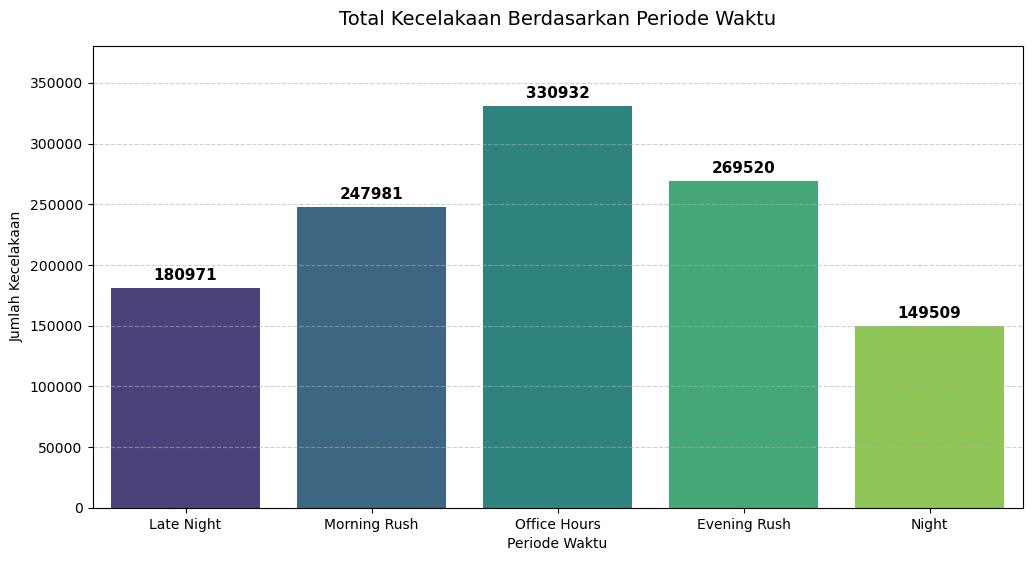

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# Gunakan order=labels agar urutan jamnya masuk akal (dari Late Night ke Night)
ax = sns.countplot(data=df, x='Time_Period', palette='viridis', order=labels)

# Menambahkan angka di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Total Kecelakaan Berdasarkan Periode Waktu', fontsize=14, pad=15)
plt.xlabel('Periode Waktu')
plt.ylabel('Jumlah Kecelakaan')
plt.ylim(0, df['Time_Period'].value_counts().max() * 1.15) # Memberi ruang untuk label
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

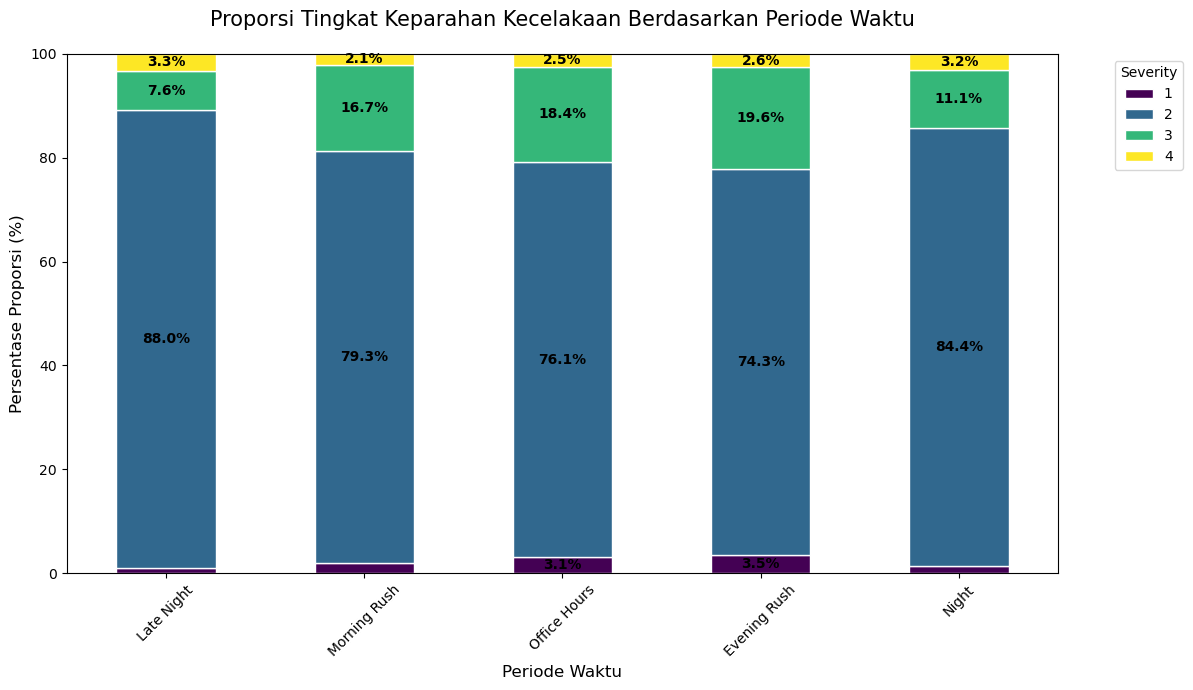

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


time_severity = pd.crosstab(df['Time_Period'], df['Severity'])
time_severity = time_severity.reindex(['Late Night', 'Morning Rush', 'Office Hours', 'Evening Rush', 'Night'])


time_severity_pct = time_severity.div(time_severity.sum(1), axis=0) * 100

# 3. Plotting
ax = time_severity_pct.plot(kind='bar', 
                            stacked=True, 
                            figsize=(12, 7), 
                            colormap='viridis', 
                            edgecolor='white')

# 4. Menambahkan label persentase di dalam setiap segmen bar
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 2:  # Label hanya muncul jika persentase > 2% agar tidak tumpang tindih
        x, y = p.get_xy() 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center',
                color='black',
                fontsize=10,
                fontweight='bold')

# Dekorasi Grafik
plt.title('Proporsi Tingkat Keparahan Kecelakaan Berdasarkan Periode Waktu', fontsize=15, pad=20)
plt.xlabel('Periode Waktu', fontsize=12)
plt.ylabel('Persentase Proporsi (%)', fontsize=12)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Temperature

In [13]:
temp_bins = [-100, 32, 50, 80, 200]
temp_labels = ['Freezing', 'Cold', 'Moderate', 'Hot']

df['Temp_Category'] = pd.cut(df['Temperature(F)'], bins=temp_bins, labels=temp_labels, include_lowest=True)

print("Distribusi Kategori Suhu:")
print(df['Temp_Category'].value_counts())

Distribusi Kategori Suhu:
Temp_Category
Moderate    682256
Cold        271062
Hot         142596
Freezing     82999
Name: count, dtype: int64


C:\Users\claire\AppData\Local\Temp\ipykernel_17188\1053953142.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Temp_Category', palette='viridis', order=temp_labels)


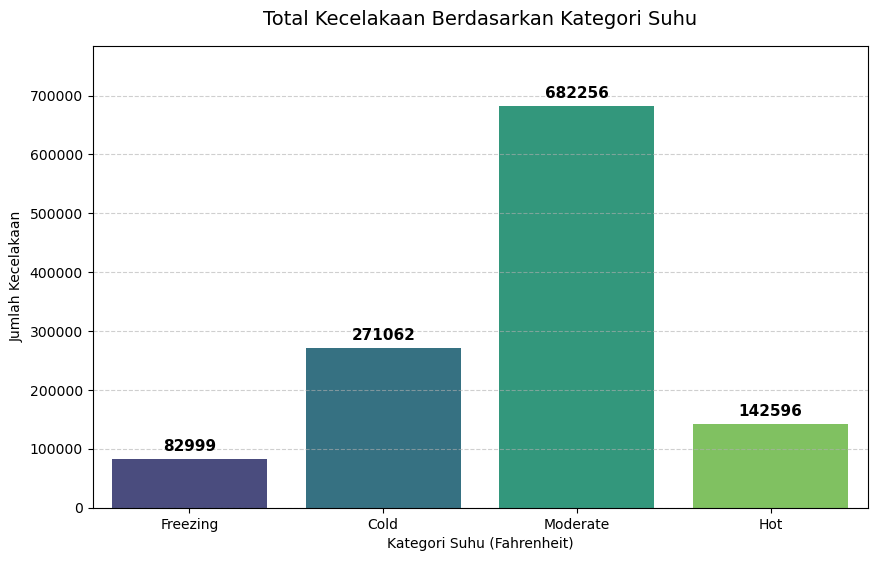

In [16]:


plt.figure(figsize=(10, 6))
# Order=temp_labels memastikan urutan dari Freezing ke Hot
ax = sns.countplot(data=df, x='Temp_Category', palette='viridis', order=temp_labels)

# Menambahkan angka di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Total Kecelakaan Berdasarkan Kategori Suhu', fontsize=14, pad=15)
plt.xlabel('Kategori Suhu (Fahrenheit)')
plt.ylabel('Jumlah Kecelakaan')

# Memberikan margin atas agar angka tidak terpotong
plt.ylim(0, df['Temp_Category'].value_counts().max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

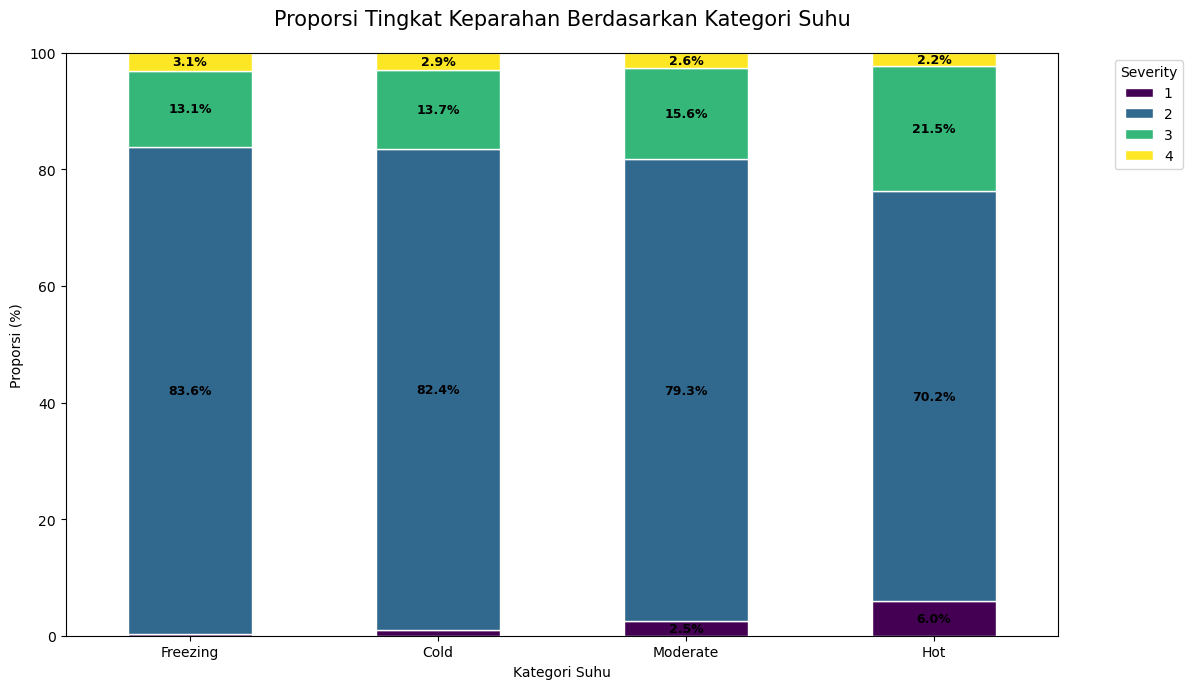

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Membuat tabel kontingensi antara kategori suhu dan tingkat keparahan
temp_severity = pd.crosstab(df['Temp_Category'], df['Severity'])

# Urutkan berdasarkan kategori suhu agar logis (dari dingin ke panas)
temp_severity = temp_severity.reindex(temp_labels)

# 2. Transformasi ke persentase (100% Stacked)
temp_severity_pct = temp_severity.div(temp_severity.sum(1), axis=0) * 100

# 3. Visualisasi
ax = temp_severity_pct.plot(kind='bar', 
                            stacked=True, 
                            figsize=(12, 7), 
                            colormap='viridis', # Warna merah-kuning-biru yang dibalik agar sesuai suhu
                            edgecolor='white')

# 4. Menambahkan label persentase di dalam batang
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 2:  # Hanya tampilkan label jika persentase di atas 2%
        x, y = p.get_xy() 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center',
                color='black', # Pakai hitam agar lebih kontras di warna terang
                fontsize=9,
                fontweight='bold')

# Detail Grafik
plt.title('Proporsi Tingkat Keparahan Berdasarkan Kategori Suhu', fontsize=15, pad=20)
plt.xlabel('Kategori Suhu')
plt.ylabel('Proporsi (%)')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0) # Dibuat horizontal agar mudah dibaca
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Distance

In [14]:
dist_bins = [0, 0.5, 2.0, 10.0, 500]
dist_labels = ['Very Local', 'Short Distance', 'Long Distance', 'Extreme Impact']

df['Distance_Category'] = pd.cut(df['Distance(mi)'], bins=dist_bins, labels=dist_labels, include_lowest=True)

print("Distribusi Kategori Jarak Terdampak:")
print(df['Distance_Category'].value_counts())

Distribusi Kategori Jarak Terdampak:
Distance_Category
Very Local        957948
Short Distance    152533
Long Distance      63709
Extreme Impact      4723
Name: count, dtype: int64


C:\Users\claire\AppData\Local\Temp\ipykernel_17188\2054473760.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Distance_Category', palette='viridis', order=dist_labels)


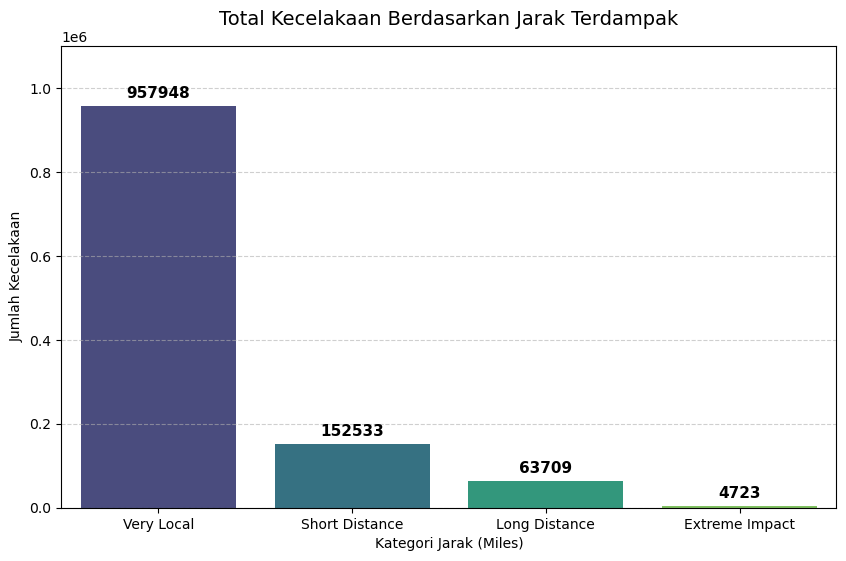

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Order=dist_labels untuk memastikan urutan dari Very Local ke Extreme Impact
ax = sns.countplot(data=df, x='Distance_Category', palette='viridis', order=dist_labels)

# Menambahkan angka di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Total Kecelakaan Berdasarkan Jarak Terdampak', fontsize=14, pad=15)
plt.xlabel('Kategori Jarak (Miles)')
plt.ylabel('Jumlah Kecelakaan')

# Memberikan margin atas agar angka tidak terpotong
plt.ylim(0, df['Distance_Category'].value_counts().max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

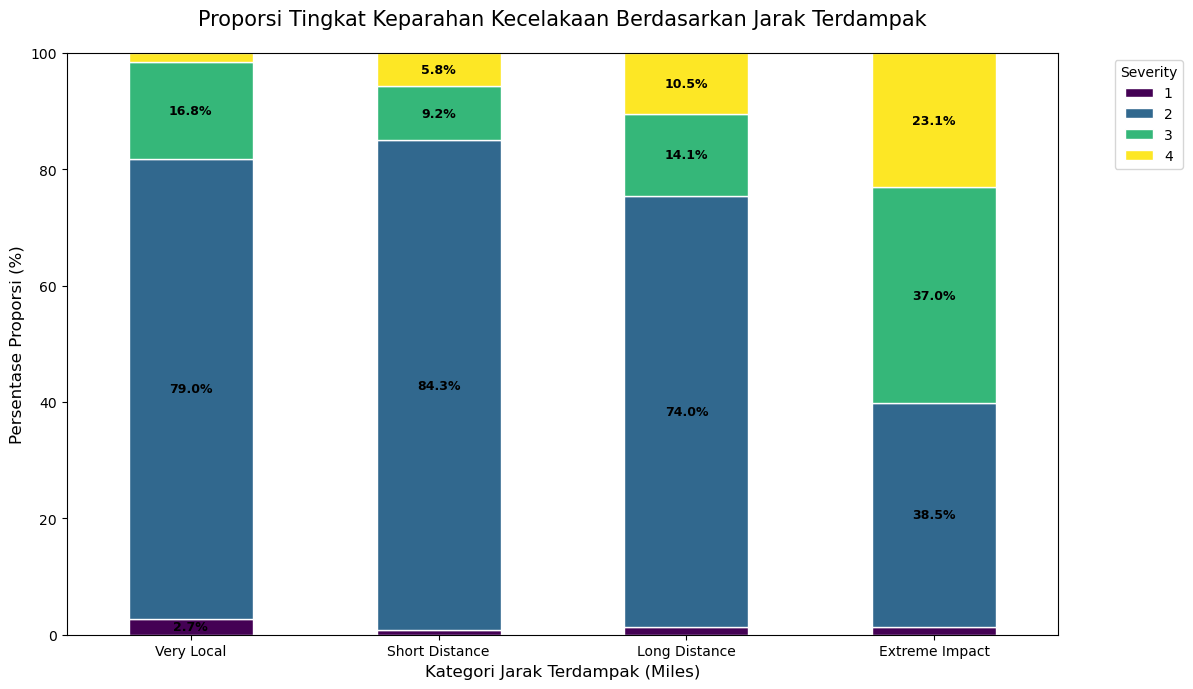

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Membuat tabel kontingensi (Crosstab)
# Menggunakan labels yang sudah didefinisikan sebelumnya agar urutan kategori konsisten
dist_severity = pd.crosstab(df['Distance_Category'], df['Severity'])
dist_severity = dist_severity.reindex(dist_labels)

# 2. Menghitung proporsi (persentase)
dist_severity_pct = dist_severity.div(dist_severity.sum(1), axis=0) * 100

# 3. Visualisasi
ax = dist_severity_pct.plot(kind='bar', 
                            stacked=True, 
                            figsize=(12, 7), 
                            colormap='viridis', 
                            edgecolor='white')

# 4. Menambahkan label persentase di dalam segmen batang
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 2:  # Label hanya muncul jika proporsi > 2% agar tidak tumpang tindih
        x, y = p.get_xy() 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center',
                color='black',
                fontsize=9,
                fontweight='bold')

# Detail Estetika Grafik
plt.title('Proporsi Tingkat Keparahan Kecelakaan Berdasarkan Jarak Terdampak', fontsize=15, pad=20)
plt.xlabel('Kategori Jarak Terdampak (Miles)', fontsize=12)
plt.ylabel('Persentase Proporsi (%)', fontsize=12)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0) # Dibuat 0 derajat agar label kategori mudah dibaca
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Duration

In [15]:
dur_bins = [0, 720, 1440, 2160, 100000]
dur_labels = ['Short (<12h)', 'Medium (12-24h)', 'Long (24-36h)', 'Extreme (>36h)']

df['Duration_Category'] = pd.cut(df['Duration'], bins=dur_bins, labels=dur_labels, include_lowest=True)


print("Distribusi Durasi Dampak Kecelakaan:")
print(df['Duration_Category'].value_counts())

Distribusi Durasi Dampak Kecelakaan:
Duration_Category
Short (<12h)       1151383
Medium (12-24h)      20878
Long (24-36h)         3491
Extreme (>36h)        3161
Name: count, dtype: int64


C:\Users\claire\AppData\Local\Temp\ipykernel_17188\3918688853.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Duration_Category', palette='viridis')


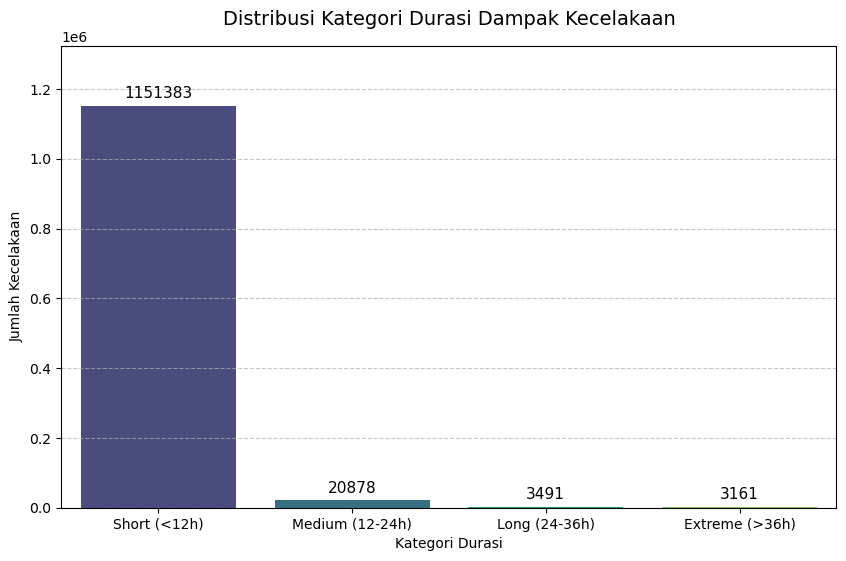

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Simpan plot ke dalam variabel 'ax'
ax = sns.countplot(data=df, x='Duration_Category', palette='viridis')

# Tambahkan angka di atas setiap batang
for p in ax.patches:
    # Ambil tinggi batang sebagai nilai jumlah
    height = p.get_height()
    # Tulis teks di atas batang
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11)

plt.title('Distribusi Kategori Durasi Dampak Kecelakaan', fontsize=14, pad=15)
plt.xlabel('Kategori Durasi')
plt.ylabel('Jumlah Kecelakaan')

# Memberikan ruang tambahan di atas sumbu y agar angka tidak terpotong
plt.ylim(0, df['Duration_Category'].value_counts().max() * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

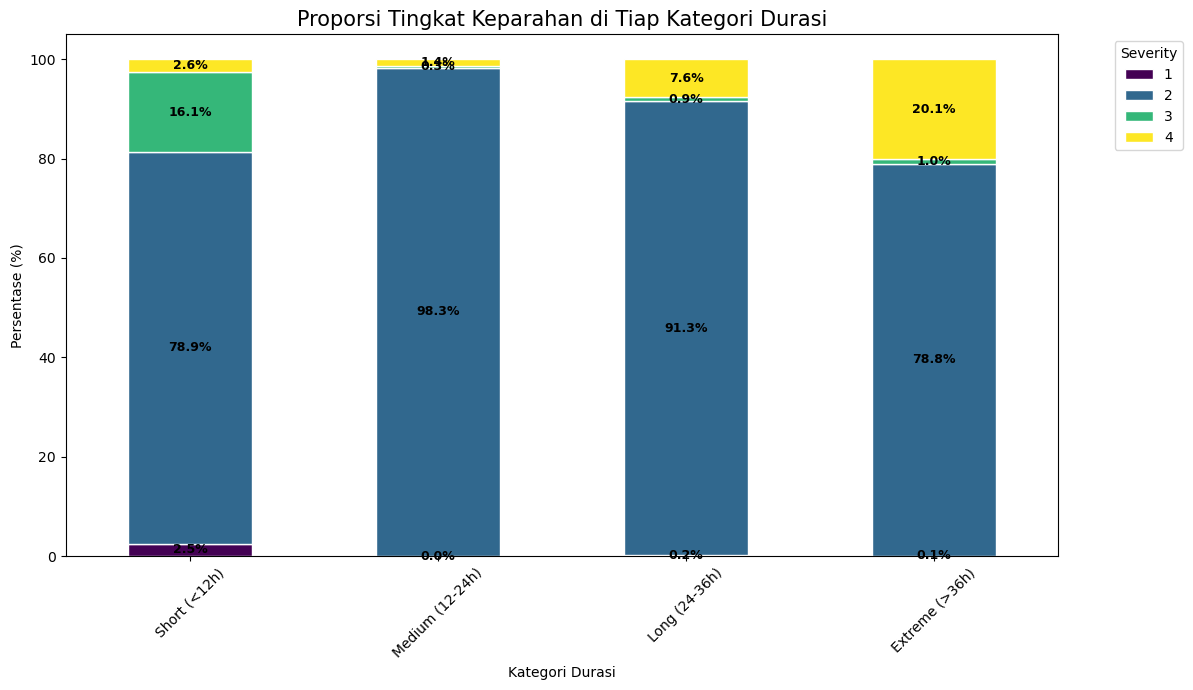

In [22]:
# 1. Hitung persentase
stacked_data = pd.crosstab(df['Duration_Category'], df['Severity'])
stacked_data_pct = stacked_data.div(stacked_data.sum(1), axis=0) * 100

# 2. Plotting
ax = stacked_data_pct.plot(kind='bar', 
                           stacked=True, 
                           figsize=(12, 7), 
                           colormap='viridis', 
                           edgecolor='white')

# Tambahkan label persentase di dalam bar
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        x, y = p.get_xy() 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', # Format 1 angka di belakang koma
                horizontalalignment='center', 
                verticalalignment='center',
                color='black',
                fontweight='bold',
                fontsize=9)

plt.title('Proporsi Tingkat Keparahan di Tiap Kategori Durasi', fontsize=15)
plt.ylabel('Persentase (%)')
plt.xlabel('Kategori Durasi')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visibility

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

vis_bins = [0, 1.0, 4.0, 7.0, 11.0] 
vis_labels = ['Foggy (<1mi)', 'Poor (1-4mi)', 'Moderate (4-7mi)', 'Clear (>7mi)']

df['Visibility_Category'] = pd.cut(df['Visibility(mi)'], bins=vis_bins, labels=vis_labels, include_lowest=True)

print("Distribusi Visibilitas:")
print(df['Visibility_Category'].value_counts().reindex(vis_labels))

Distribusi Visibilitas:
Visibility_Category
Foggy (<1mi)         36808
Poor (1-4mi)         62419
Moderate (4-7mi)     82522
Clear (>7mi)        997164
Name: count, dtype: int64


C:\Users\claire\AppData\Local\Temp\ipykernel_17188\3754741357.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Visibility_Category', palette='viridis', order=vis_labels)


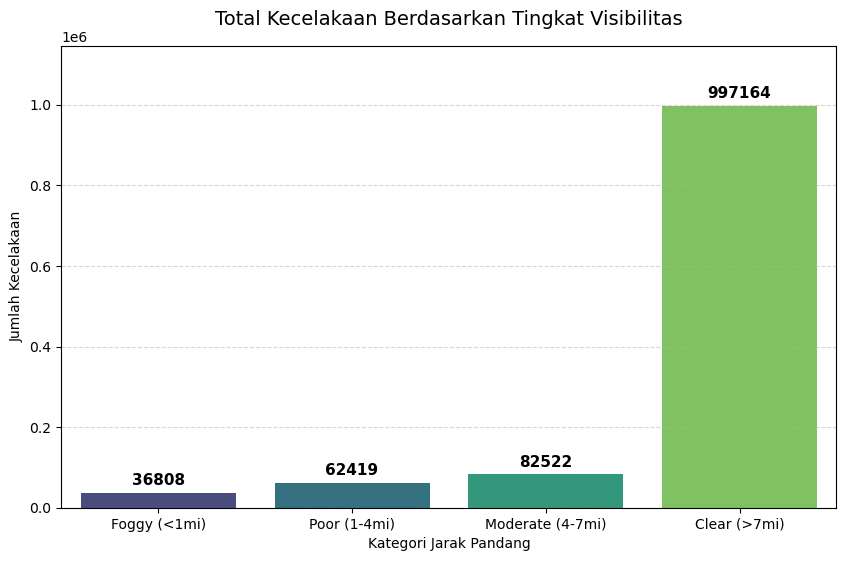

In [30]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Visibility_Category', palette='viridis', order=vis_labels)

# Tambahkan angka di atas batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Total Kecelakaan Berdasarkan Tingkat Visibilitas', fontsize=14, pad=15)
plt.xlabel('Kategori Jarak Pandang')
plt.ylabel('Jumlah Kecelakaan')
plt.ylim(0, df['Visibility_Category'].value_counts().max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

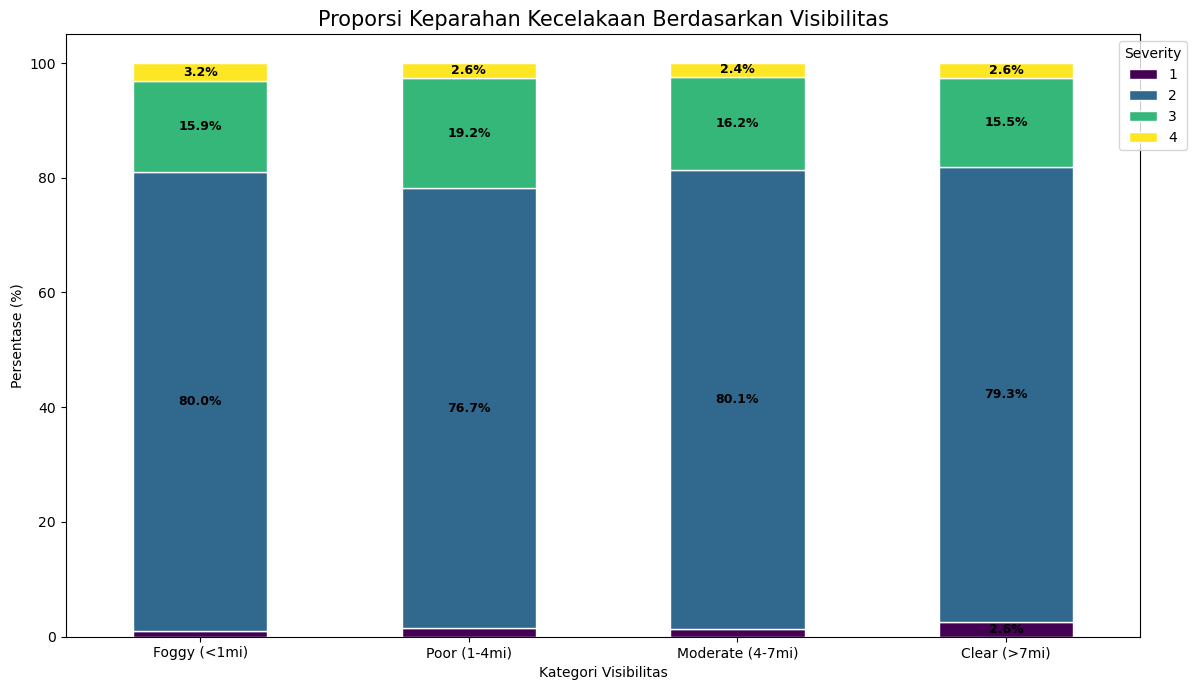

In [34]:
# Membuat tabel proporsi
vis_severity_pct = pd.crosstab(df['Visibility_Category'], df['Severity'])
vis_severity_pct = vis_severity_pct.reindex(vis_labels).div(vis_severity_pct.sum(1), axis=0) * 100

# Plotting
ax = vis_severity_pct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', edgecolor='white')

# Tambahkan label persentase
for p in ax.patches:
    h = p.get_height()
    if h > 2: # Tampilkan jika lebih dari 2%
        ax.text(p.get_x() + p.get_width()/2, p.get_y() + h/2, f'{h:.1f}%', 
                ha='center', va='center', color='black', fontsize=9, fontweight='bold')

plt.title('Proporsi Keparahan Kecelakaan Berdasarkan Visibilitas', fontsize=15)
plt.ylabel('Persentase (%)')
plt.xlabel('Kategori Visibilitas')
plt.xticks(rotation=0)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Humidity

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Definisi rentang kelembapan (Asumsi skala 0-100%, jika datamu 1-10 tinggal sesuaikan angka binnnya)
# Jika datamu murni 1-10, gunakan bins = [0, 3, 6, 8, 11]
hum_bins = [0, 30, 60, 80, 100] 
hum_labels = ['Very Dry (<30%)', 'Comfortable (30-60%)', 'Humid (60-80%)', 'Very Humid (>80%)']

df['Humidity_Category'] = pd.cut(df['Humidity(%)'], bins=hum_bins, labels=hum_labels, include_lowest=True)

# Tampilkan ringkasan angka
print("Distribusi Kelembapan:")
print(df['Humidity_Category'].value_counts().reindex(hum_labels))

Distribusi Kelembapan:
Humidity_Category
Very Dry (<30%)         105485
Comfortable (30-60%)    335551
Humid (60-80%)          340332
Very Humid (>80%)       397545
Name: count, dtype: int64


C:\Users\claire\AppData\Local\Temp\ipykernel_17188\1688623478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Humidity_Category', palette='viridis', order=hum_labels)


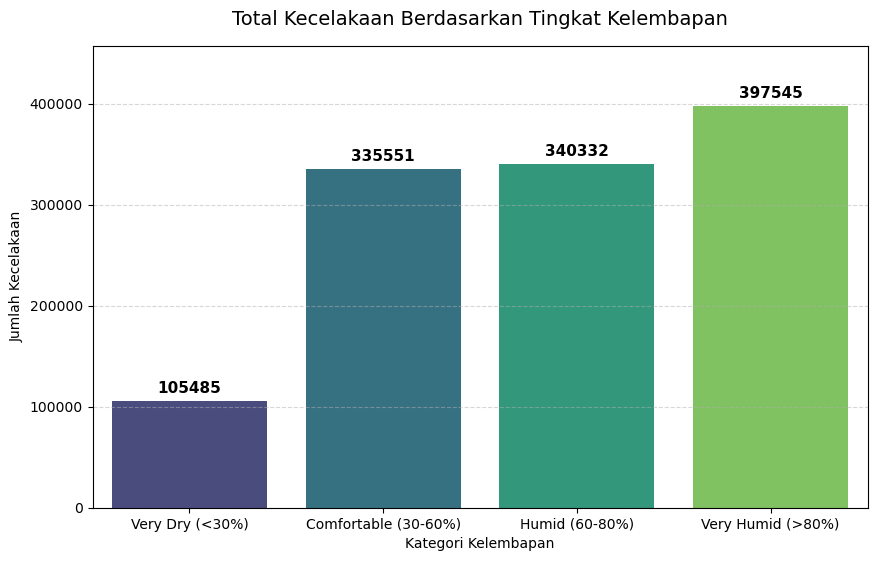

In [37]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Humidity_Category', palette='viridis', order=hum_labels)

# Tambahkan angka di atas batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Total Kecelakaan Berdasarkan Tingkat Kelembapan', fontsize=14, pad=15)
plt.xlabel('Kategori Kelembapan')
plt.ylabel('Jumlah Kecelakaan')
plt.ylim(0, df['Humidity_Category'].value_counts().max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

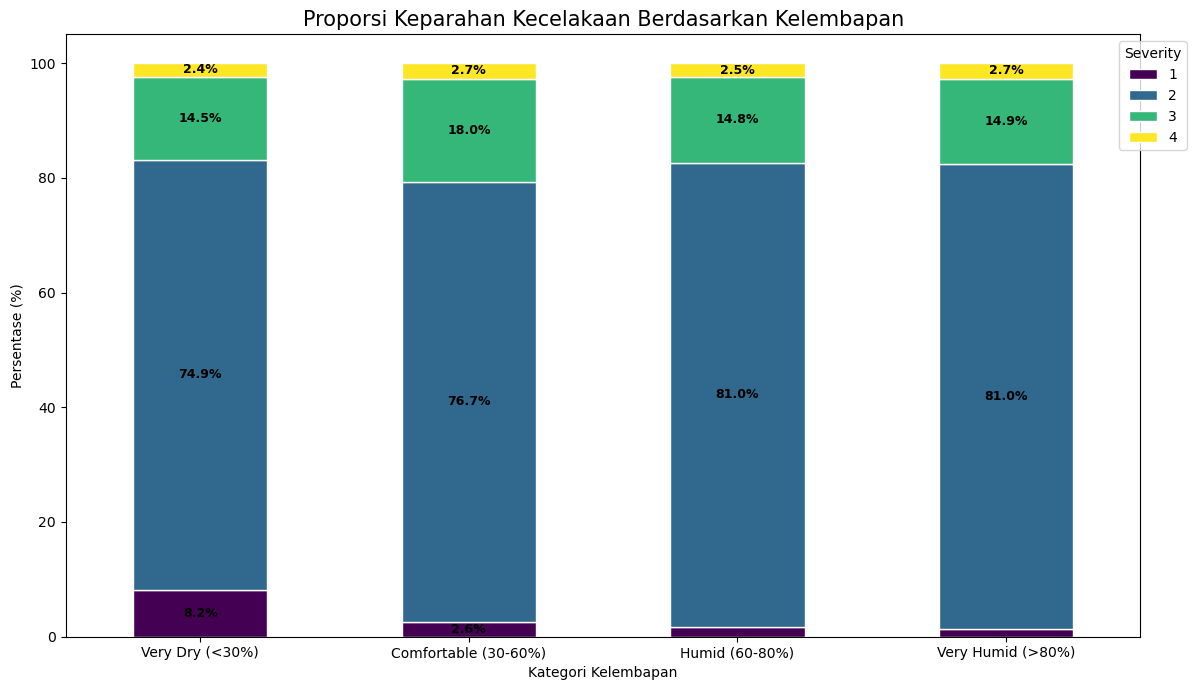

In [39]:
# Membuat tabel proporsi
hum_severity_pct = pd.crosstab(df['Humidity_Category'], df['Severity'])
hum_severity_pct = hum_severity_pct.reindex(hum_labels).div(hum_severity_pct.sum(1), axis=0) * 100

# Plotting
ax = hum_severity_pct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', edgecolor='white')

# Tambahkan label persentase
for p in ax.patches:
    h = p.get_height()
    if h > 2:
        ax.text(p.get_x() + p.get_width()/2, p.get_y() + h/2, f'{h:.1f}%', 
                ha='center', va='center', color='black', fontsize=9, fontweight='bold')

plt.title('Proporsi Keparahan Kecelakaan Berdasarkan Kelembapan', fontsize=15)
plt.ylabel('Persentase (%)')
plt.xlabel('Kategori Kelembapan')
plt.xticks(rotation=0)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Pressure

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Menentukan batas berdasarkan statistik (min: 22.1, max: 30.7)
pres_bins = [0, 29.0, 30.0, 40.0] 
pres_labels = ['Low Pressure (<29)', 'Normal Pressure (29-30)', 'High Pressure (>30)']

df['Pressure_Category'] = pd.cut(df['Pressure(in)'], bins=pres_bins, labels=pres_labels, include_lowest=True)

# Tampilkan ringkasan angka
print("Distribusi Tekanan Udara (Pressure):")
print(df['Pressure_Category'].value_counts().reindex(pres_labels))

Distribusi Tekanan Udara (Pressure):
Pressure_Category
Low Pressure (<29)         223347
Normal Pressure (29-30)    737157
High Pressure (>30)        218409
Name: count, dtype: int64


C:\Users\claire\AppData\Local\Temp\ipykernel_17188\953323922.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Pressure_Category', palette='viridis', order=pres_labels)


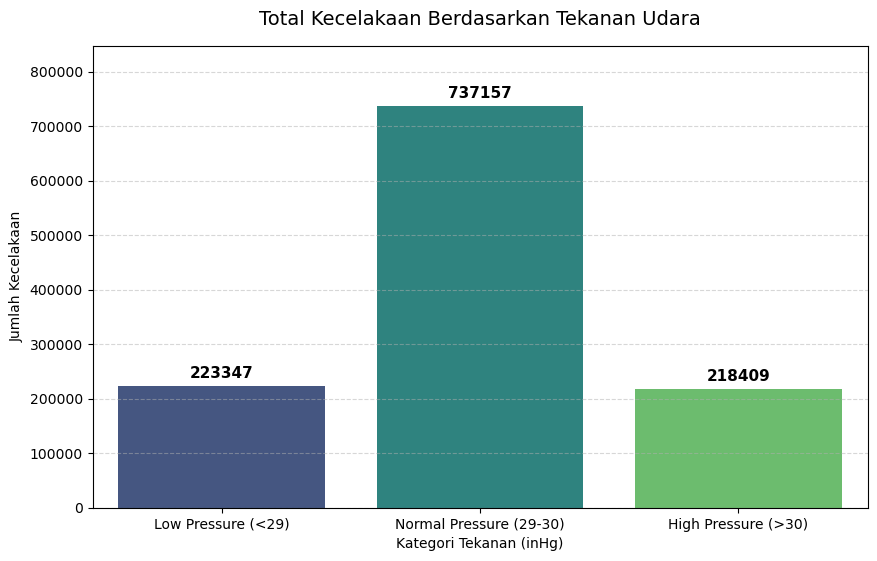

In [43]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Pressure_Category', palette='viridis', order=pres_labels)

# Tambahkan angka di atas batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Total Kecelakaan Berdasarkan Tekanan Udara', fontsize=14, pad=15)
plt.xlabel('Kategori Tekanan (inHg)')
plt.ylabel('Jumlah Kecelakaan')
plt.ylim(0, df['Pressure_Category'].value_counts().max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

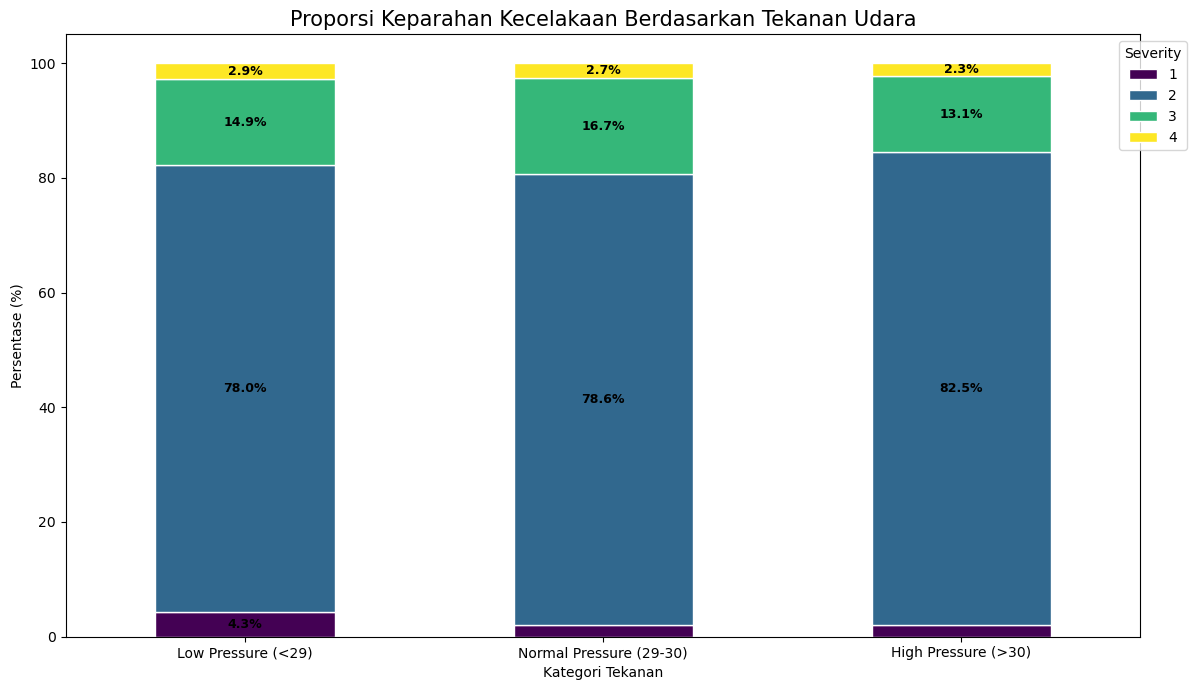

In [44]:
# Membuat tabel proporsi
pres_severity_pct = pd.crosstab(df['Pressure_Category'], df['Severity'])
pres_severity_pct = pres_severity_pct.reindex(pres_labels).div(pres_severity_pct.sum(1), axis=0) * 100

# Plotting
ax = pres_severity_pct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', edgecolor='white')

# Tambahkan label persentase
for p in ax.patches:
    h = p.get_height()
    if h > 2:
        ax.text(p.get_x() + p.get_width()/2, p.get_y() + h/2, f'{h:.1f}%', 
                ha='center', va='center', color='black', fontsize=9, fontweight='bold')

plt.title('Proporsi Keparahan Kecelakaan Berdasarkan Tekanan Udara', fontsize=15)
plt.ylabel('Persentase (%)')
plt.xlabel('Kategori Tekanan')
plt.xticks(rotation=0)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Weather Condition

C:\Users\claire\AppData\Local\Temp\ipykernel_17188\703566407.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df,


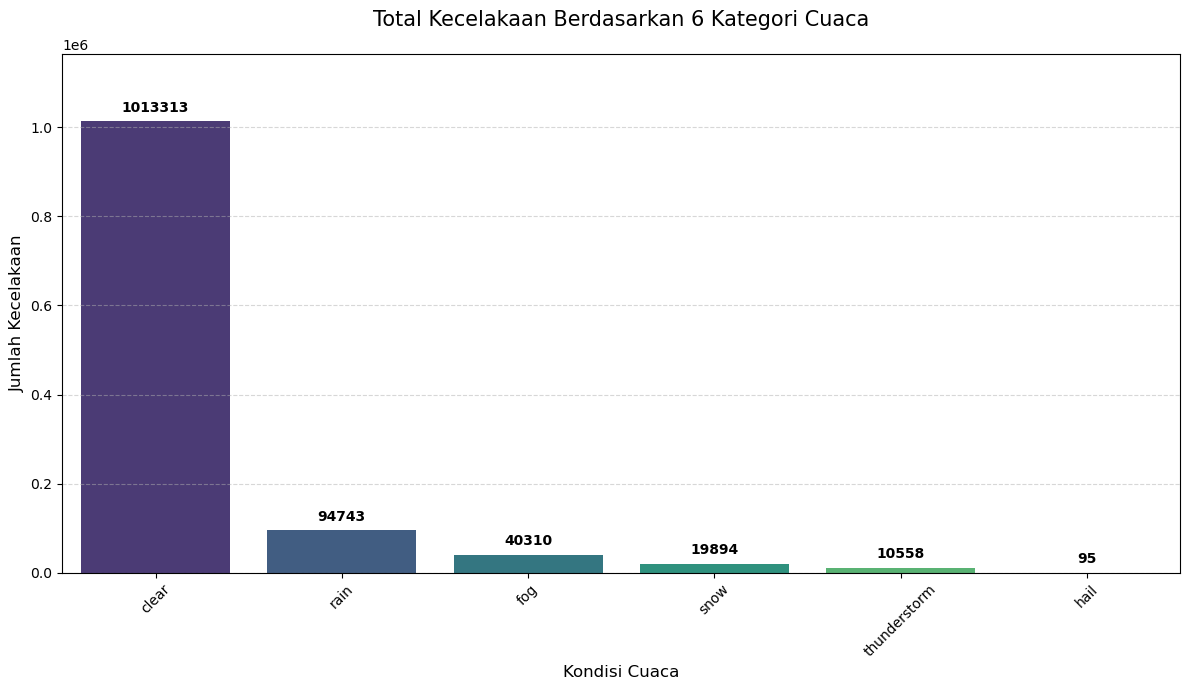

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
# Mengurutkan dari jumlah kecelakaan terbanyak (opsional, agar visual lebih rapi)
weather_order = df['Weather_Condition'].value_counts().index

ax = sns.countplot(data=df, 
                   x='Weather_Condition', 
                   palette='viridis', 
                   order=weather_order)

# Menambahkan angka total di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.title('Total Kecelakaan Berdasarkan 6 Kategori Cuaca', fontsize=15, pad=20)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Jumlah Kecelakaan', fontsize=12)
plt.xticks(rotation=45) # Memiringkan teks agar tidak bertabrakan
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Memberikan ruang di atas agar angka tidak terpotong
plt.ylim(0, df['Weather_Condition'].value_counts().max() * 1.15)

plt.tight_layout()
plt.show()

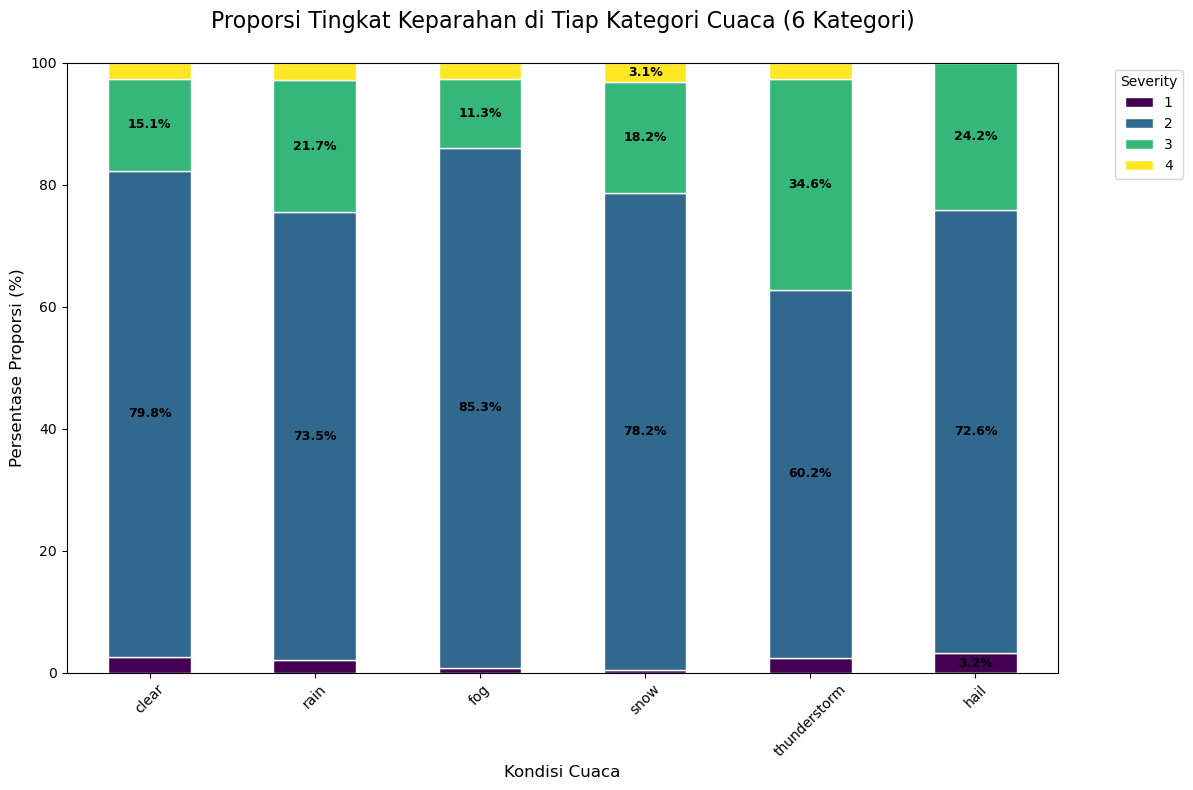

In [50]:
# 1. Membuat tabel kontingensi (Crosstab)
weather_severity = pd.crosstab(df['Weather_Condition'], df['Severity'])

# 2. Transformasi ke persentase (Total per batang = 100%)
weather_severity_pct = weather_severity.div(weather_severity.sum(1), axis=0) * 100

# Urutkan berdasarkan urutan jumlah terbanyak agar konsisten
weather_severity_pct = weather_severity_pct.reindex(weather_order)

# 3. Plotting Vertical Stacked Bar
ax = weather_severity_pct.plot(kind='bar', 
                               stacked=True, 
                               figsize=(12, 8), 
                               colormap='viridis', 
                               edgecolor='white')

# 4. Menambahkan label persentase di dalam segmen batang
for p in ax.patches:
    height = p.get_height()
    if height > 3:  # Tampilkan angka jika persentase segmen > 3%
        x, y = p.get_xy() 
        ax.text(x + p.get_width()/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', va='center',
                color='black', fontsize=9, fontweight='bold')

plt.title('Proporsi Tingkat Keparahan di Tiap Kategori Cuaca (6 Kategori)', fontsize=16, pad=25)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Persentase Proporsi (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

# Feature Selection

In [19]:
X = df.drop(columns=['Severity'])
y = df['Severity']

## Mutual Information

In [19]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X_check = X.copy()
y_check = y.copy()

X_check = X_check.sample(n=50000, random_state=42)
y_check = y_check.loc[X_check.index]

le = LabelEncoder()

for col in X_check.columns:
    if str(X_check[col].dtype) in ['category', 'object', 'bool']:
        X_check[col] = le.fit_transform(X_check[col].astype(str))

    else:
        X_check[col] = X_check[col].astype(float)

X_check = X_check.fillna(0)

discrete_cols = [True if str(X[col].dtype) in ['category', 'int64', 'bool'] else False for col in X.columns]

mi_scores = mutual_info_classif(
    X_check,
    y_check,
    discrete_features=discrete_cols,
    random_state=42
)

mi_results = pd.DataFrame({'Feature': X_check.columns, 'MI_Score': mi_scores})
mi_results = mi_results.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

print(mi_results)

                  Feature  MI_Score
0                    City  0.193538
1                Duration  0.129543
2                  County  0.121402
3            Distance(mi)  0.071232
4                   State  0.059108
5                   Month  0.056859
6            Pressure(in)  0.014640
7                    Hour  0.014510
8       Distance_Category  0.014510
9   Astronomical_Twilight  0.013248
10          Road_Features  0.012300
11         Temperature(F)  0.012038
12         Traffic_Signal  0.010964
13            Humidity(%)  0.010441
14            Time_Period  0.010002
15               Crossing  0.009359
16          Temp_Category  0.007422
17         Visibility(mi)  0.006665
18        Wind_Speed(mph)  0.005689
19      Duration_Category  0.005173
20         Wind_Direction  0.004019
21      Weather_Condition  0.003637
22       Is_Precipitating  0.001928
23                   Stop  0.001416
24      Precipitation(in)  0.001140
25                Station  0.000797
26               Junction  0

## Spearman

In [20]:
df_spearman = X.copy()
df_spearman['Target_Severity'] = y

for col in df_spearman.columns:
    if str(df_spearman[col].dtype) in ['category', 'object', 'bool']:
        df_spearman[col] = df_spearman[col].astype('category').cat.codes
    else:
        df_spearman[col] = df_spearman[col].astype(float)

spearman_matrix = df_spearman.corr(method='spearman')

spearman_results = spearman_matrix['Target_Severity'].drop('Target_Severity').to_frame()
spearman_results.columns = ['Correlation_Score']
spearman_results['Absolute_Score'] = spearman_results['Correlation_Score'].abs()

spearman_results = spearman_results.sort_values(by='Absolute_Score', ascending=False)

print("Hasil Korelasi Spearman terhadap Severity:")
print(spearman_results[['Correlation_Score']])

Hasil Korelasi Spearman terhadap Severity:
                       Correlation_Score
Duration                       -0.146731
Traffic_Signal                 -0.126315
Road_Features                  -0.126018
Crossing                       -0.118957
Month                          -0.108812
State                           0.090639
Astronomical_Twilight           0.088221
County                         -0.081138
City                           -0.058987
Wind_Speed(mph)                 0.057529
Precipitation(in)               0.052700
Is_Precipitating                0.051737
Weather_Condition               0.048017
Distance(mi)                   -0.044628
Stop                           -0.042411
Duration_Category              -0.040102
Station                        -0.037458
Distance_Category               0.034578
Pressure(in)                   -0.032247
Junction                        0.031145
Hour                            0.030854
Time_Period                     0.030437
Wind_Direction

## Cramer's V

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def calculate_cramers_v(x, y):
    """
    Menghitung Cramér's V dengan koreksi bias untuk dua variabel kategori.
    """
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    if n == 0: return 0

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)

    denominator = min((k_corr-1), (r_corr-1))
    if denominator <= 0: return 0

    return np.sqrt(phi2_corr / denominator)

n_target_samples = 100000
actual_n = min(len(X_check), n_target_samples)

cat_cols = [
    'City', 'County', 'State', 'Wind_Direction', 'Weather_Condition', 'Time_Period', 'Temp_Category',
    'Distance_Category', 'Duration_Category', 'Month', 'Day', 'Hour', 'Road_Features', 'Amenity',
    'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
    'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Is_Weekend', 'Is_Precipitating'
]

cramers_list = []

for col in cat_cols:
    if col in X_check.columns:
        sample_x = X_check[col].sample(n=actual_n, random_state=42)
        sample_y = y_check.loc[sample_x.index]

        score = calculate_cramers_v(sample_x, sample_y)

        cramers_list.append({
            'Feature': col,
            "Cramer's V": round(score, 4)
        })

cramers_df = pd.DataFrame(cramers_list).sort_values(by="Cramer's V", ascending=False)

print("\nTabel Kekuatan Asosiasi (Cramér's V) terhadap Severity")
print(cramers_df.to_markdown(index=False))


Tabel Kekuatan Asosiasi (Cramér's V) terhadap Severity
| Feature           |   Cramer's V |
|:------------------|-------------:|
| City              |       0.3361 |
| County            |       0.3079 |
| State             |       0.2276 |
| Month             |       0.1947 |
| Traffic_Signal    |       0.1562 |
| Crossing          |       0.146  |
| Distance_Category |       0.1145 |
| Road_Features     |       0.0965 |
| Hour              |       0.0881 |
| Time_Period       |       0.0777 |
| Temp_Category     |       0.0704 |
| Is_Precipitating  |       0.0648 |
| Duration_Category |       0.0589 |
| Weather_Condition |       0.0501 |
| Wind_Direction    |       0.0496 |
| Stop              |       0.0469 |
| Station           |       0.0364 |
| Junction          |       0.035  |
| Amenity           |       0.0308 |
| Is_Weekend        |       0.0293 |
| Day               |       0.0172 |
| Give_Way          |       0.0144 |
| Railway           |       0.0127 |
| Traffic_Calming  

## Keputusan
Membuang kolom Roundabout, Bump, No_Exit, Traffic Calming, Give_Way, Railway, Amenity

# Interpretasi Data

## State

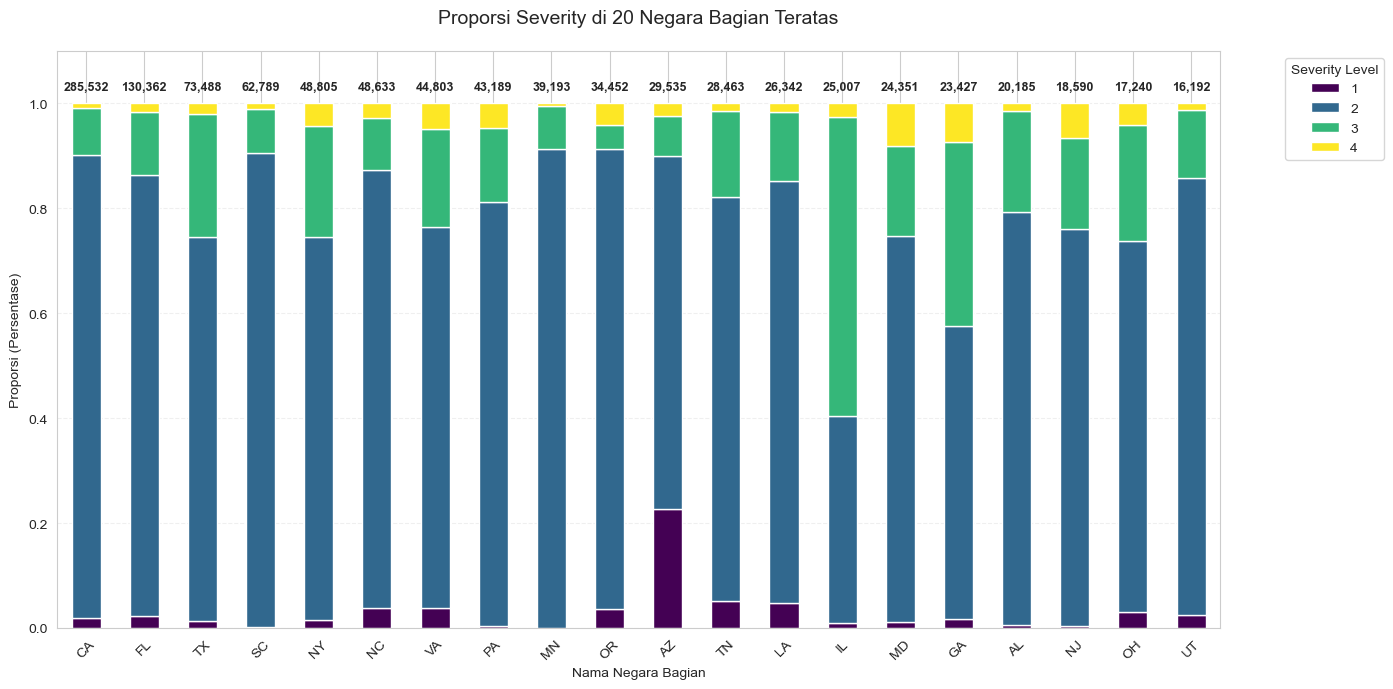

In [107]:
import matplotlib.pyplot as plt

# 1. Ambil urutan kota berdasarkan jumlah terbanyak (Value Counts)
top_cities = df['State'].value_counts().nlargest(20).index

# 2. Filter dataframe
df_subset = df[df['State'].isin(top_cities)]

# 3. Buat crosstab
cross_tab = pd.crosstab(df_subset['State'], df_subset['Severity'], normalize='index')

# 4. REVISI UTAMA: Urutkan ulang crosstab berdasarkan urutan top_cities
cross_tab = cross_tab.reindex(top_cities)

# 5. Plotting
ax = cross_tab.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis', edgecolor='white')

# 6. Menambahkan angka presisi (Persentase) di atas batang
for i, city in enumerate(top_cities):
    # Kita ambil total jumlah asli untuk ditampilkan di atas bar (opsional)
    # Atau jika ingin menampilkan total populasi per kota:
    total_count = df['State'].value_counts()[city]
    ax.text(i, 1.02, f'{total_count:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.title("Proporsi Severity di 20 Negara Bagian Teratas", fontsize=14, pad=20)
plt.ylabel("Proporsi (Persentase)")
plt.xlabel("Nama Negara Bagian")
plt.legend(title="Severity Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.ylim(0, 1.1) # Memberi ruang untuk teks angka di atas
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Kota

In [99]:
df_plot = df.copy()
df_plot['Severity'] = df_plot['Severity'].astype(int)

In [100]:
top_cities = df_plot['City'].value_counts().nlargest(20).index
df_top_cities = df_plot[df_plot['City'].isin(top_cities)]

ct = pd.crosstab(df_top_cities['City'], df_top_cities['Severity'])

print(ct.head())

Severity       1      2     3    4
City                              
Atlanta      108   4464  3600  528
Austin         5  10107   879  110
Baton Rouge  479  10088   948   63
Charlotte    485  18118  1300  100
Dallas         7  12061  5337  382


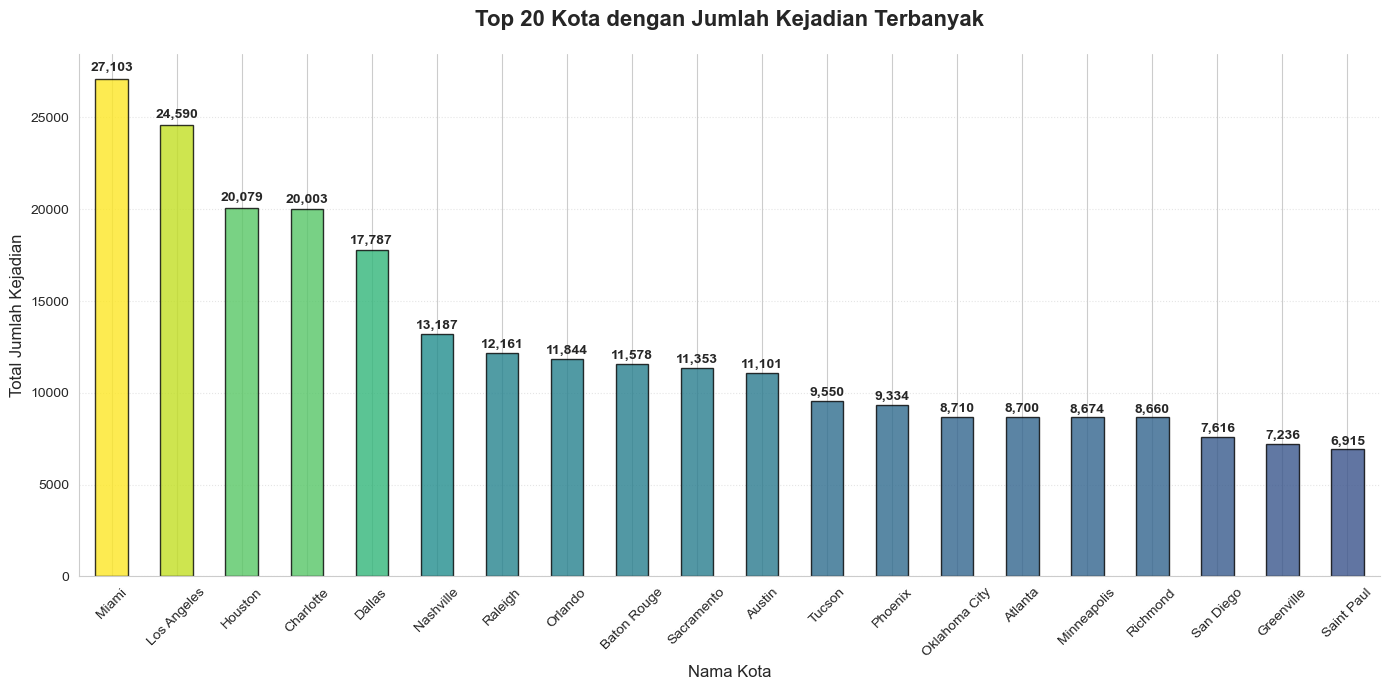

In [104]:
import matplotlib.pyplot as plt

# 1. Hitung total jumlah per kota
city_counts = ct.loc[top_cities].sum(axis=1)

# 2. Plotting dengan Color Palette (menggunakan cm.get_cmap untuk gradasi)
plt.figure(figsize=(14, 7))
colors = plt.cm.viridis(city_counts.values / max(city_counts.values)) # Gradasi berdasarkan nilai
ax = city_counts.plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)

# 3. Menambahkan angka presisi di atas setiap batang
for i, v in enumerate(city_counts):
    ax.text(i, v + (v * 0.01), f'{int(v):,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 4. Estetika Grafik
plt.title('Top 20 Kota dengan Jumlah Kejadian Terbanyak', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nama Kota', fontsize=12)
plt.ylabel('Total Jumlah Kejadian', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Menghilangkan garis frame kanan dan atas agar lebih clean
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

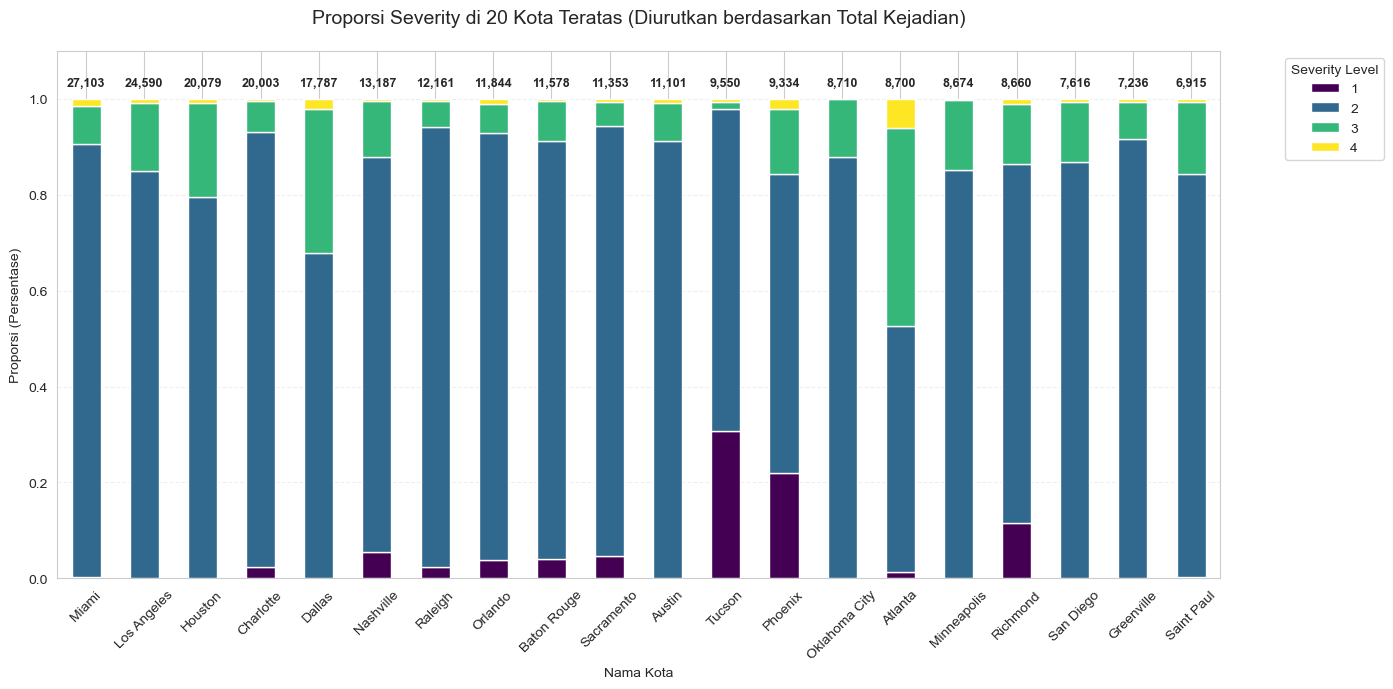

In [105]:
import matplotlib.pyplot as plt

# 1. Ambil urutan kota berdasarkan jumlah terbanyak (Value Counts)
top_cities = df['City'].value_counts().nlargest(20).index

# 2. Filter dataframe
df_subset = df[df['City'].isin(top_cities)]

# 3. Buat crosstab
cross_tab = pd.crosstab(df_subset['City'], df_subset['Severity'], normalize='index')

# 4. REVISI UTAMA: Urutkan ulang crosstab berdasarkan urutan top_cities
cross_tab = cross_tab.reindex(top_cities)

# 5. Plotting
ax = cross_tab.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis', edgecolor='white')

# 6. Menambahkan angka presisi (Persentase) di atas batang
for i, city in enumerate(top_cities):
    # Kita ambil total jumlah asli untuk ditampilkan di atas bar (opsional)
    # Atau jika ingin menampilkan total populasi per kota:
    total_count = df['City'].value_counts()[city]
    ax.text(i, 1.02, f'{total_count:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.title("Proporsi Severity di 20 Kota Teratas (Diurutkan berdasarkan Total Kejadian)", fontsize=14, pad=20)
plt.ylabel("Proporsi (Persentase)")
plt.xlabel("Nama Kota")
plt.legend(title="Severity Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.ylim(0, 1.1) # Memberi ruang untuk teks angka di atas
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Distance

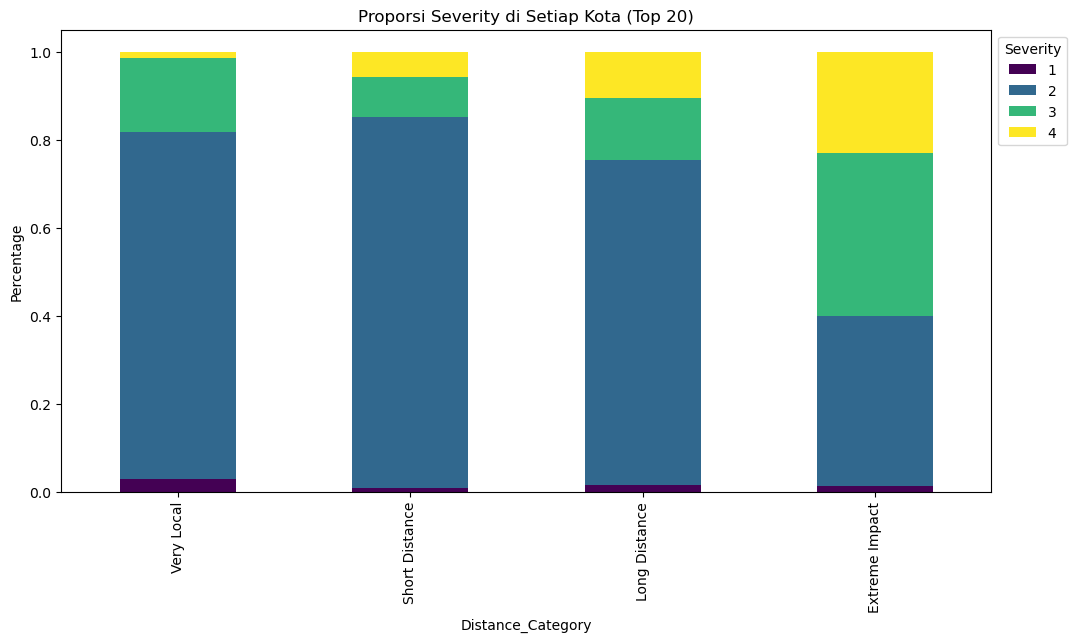

In [ ]:
top_cities = df['Distance_Category'].value_counts().nlargest(20).index
df_subset = df[df['Distance_Category'].isin(top_cities)]

cross_tab = pd.crosstab(df_subset['Distance_Category'], df_subset['Severity'], normalize='index')

cross_tab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Proporsi Severity di Distance Category")
plt.ylabel("Percentage")
plt.legend(title="Severity", bbox_to_anchor=(1, 1))
plt.show()

## Weather Condition

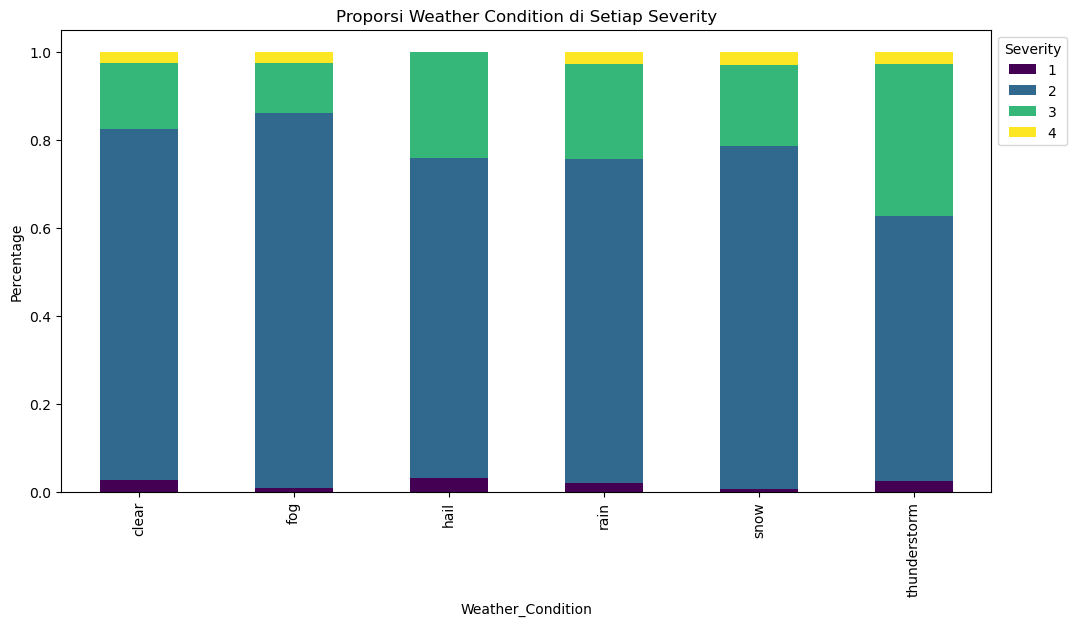

In [ ]:
top_cities = df['Weather_Condition'].value_counts().nlargest(20).index
df_subset = df[df['Weather_Condition'].isin(top_cities)]

cross_tab = pd.crosstab(df_subset['Weather_Condition'], df_subset['Severity'], normalize='index')

cross_tab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Proporsi Weather Condition di Setiap Severity (Top 20)")
plt.ylabel("Percentage")
plt.legend(title="Severity", bbox_to_anchor=(1, 1))
plt.show()

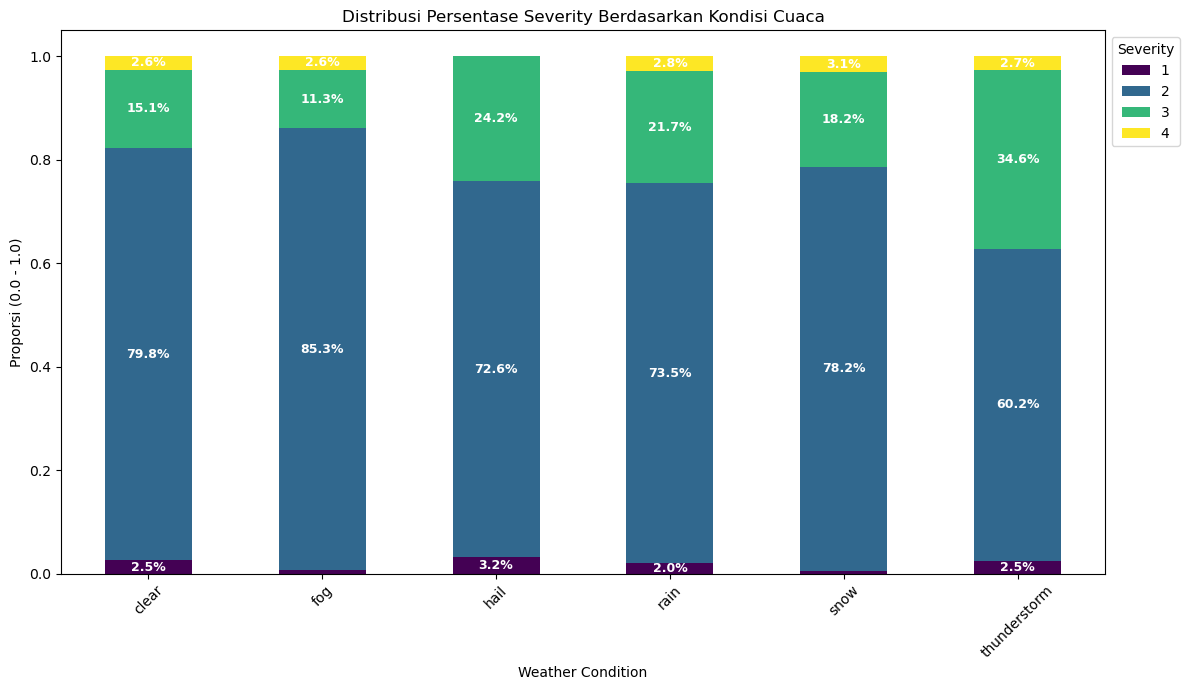

In [ ]:
top_weather = df['Weather_Condition'].value_counts().nlargest(10).index # Ambil 10 agar label tidak bertumpuk
df_subset = df[df['Weather_Condition'].isin(top_weather)]
cross_tab = pd.crosstab(df_subset['Weather_Condition'], df_subset['Severity'], normalize='index')

ax = cross_tab.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    
    if height > 0.01:
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white', 
                fontweight='bold')

plt.title("Distribusi Persentase Severity Berdasarkan Kondisi Cuaca")
plt.ylabel("Proporsi (0.0 - 1.0)")
plt.xlabel("Weather Condition")
plt.legend(title="Severity", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Temperature Category

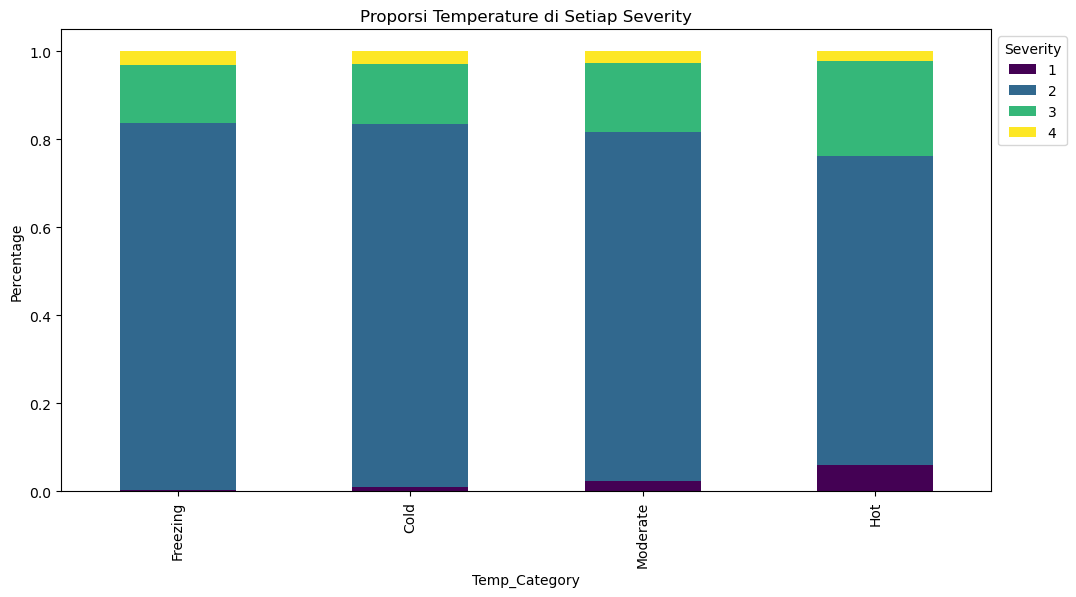

In [31]:
top_cities = df['Temp_Category'].value_counts().nlargest(20).index
df_subset = df[df['Temp_Category'].isin(top_cities)]

cross_tab = pd.crosstab(df_subset['Temp_Category'], df_subset['Severity'], normalize='index')

cross_tab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Proporsi Temperature di Setiap Severity")
plt.ylabel("Percentage")
plt.legend(title="Severity", bbox_to_anchor=(1, 1))
plt.show()

## Bulan

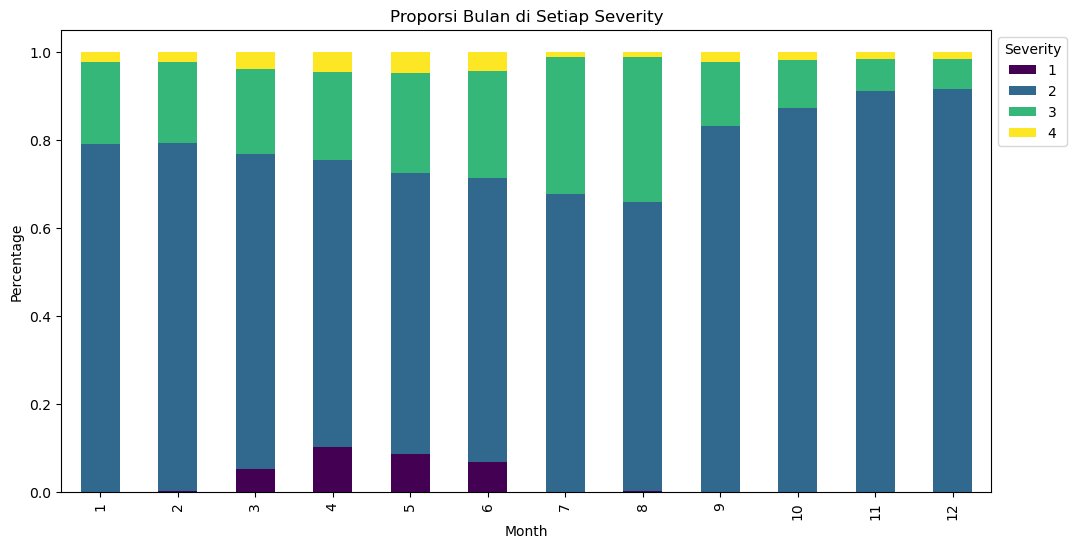

In [32]:
top_cities = df['Month'].value_counts().nlargest(20).index
df_subset = df[df['Month'].isin(top_cities)]

cross_tab = pd.crosstab(df_subset['Month'], df_subset['Severity'], normalize='index')

cross_tab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Proporsi Bulan di Setiap Severity")
plt.ylabel("Percentage")
plt.legend(title="Severity", bbox_to_anchor=(1, 1))
plt.show()

## State Wyoming

C:\Users\claire\AppData\Local\Temp\ipykernel_19388\2694435874.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wy_severity_counts.index, y=wy_severity_counts.values, palette='viridis')


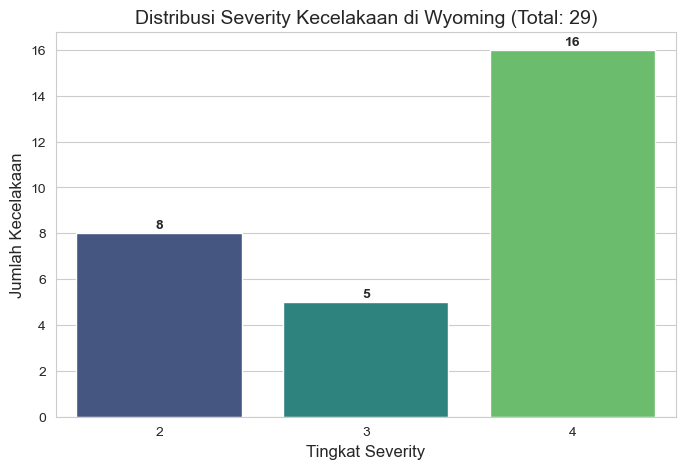

Distribusi Severity di WY:
Severity
2     8
3     5
4    16
Name: count, dtype: int64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

wy_data = df[df['State'] == 'WY']

wy_severity_counts = wy_data['Severity'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=wy_severity_counts.index, y=wy_severity_counts.values, palette='viridis')

plt.title('Distribusi Severity Kecelakaan di Wyoming (Total: 29)', fontsize=14)
plt.xlabel('Tingkat Severity', fontsize=12)
plt.ylabel('Jumlah Kecelakaan', fontsize=12)

for i, v in enumerate(wy_severity_counts.values):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.show()
print("Distribusi Severity di WY:")
print(wy_severity_counts)

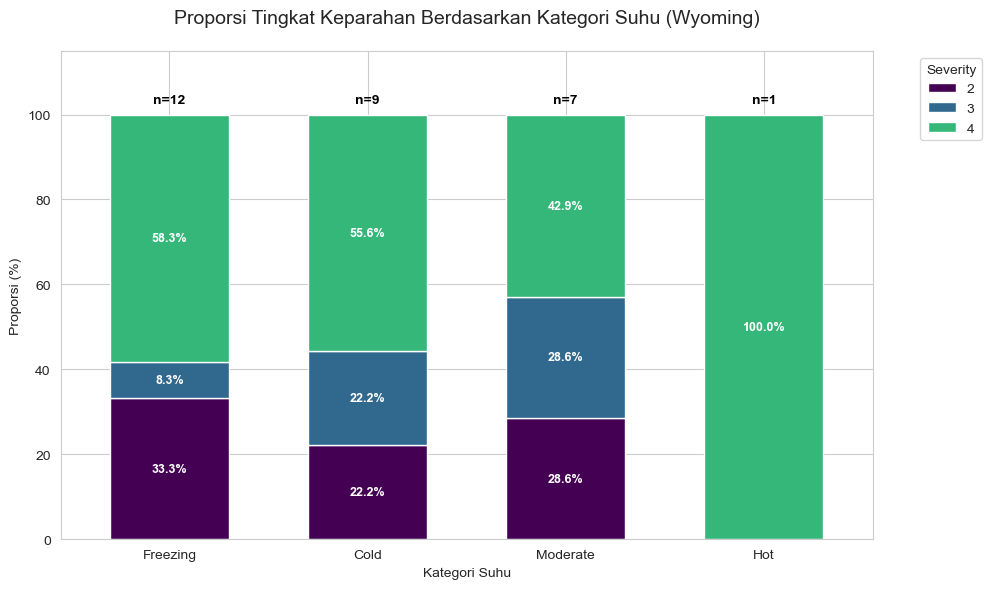

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter data khusus untuk state Wyoming
df_wyoming = df[df['State'] == 'WY'].copy()

# 2. Hitung total jumlah (counts) per kategori untuk label di atas bar
totals = df_wyoming['Temp_Category'].value_counts()

# 3. Hitung proporsi (Crosstab)
cross_tab_prop = pd.crosstab(df_wyoming['Temp_Category'], 
                             df_wyoming['Severity'], 
                             normalize='index') * 100

# Urutkan kategori
ordered_categories = ['Freezing', 'Cold', 'Moderate', 'Hot']
available_categories = [c for c in ordered_categories if c in cross_tab_prop.index]
cross_tab_prop = cross_tab_prop.reindex(available_categories)
totals = totals.reindex(available_categories) # Samakan urutan total dengan kategori

# 4. Plotting
ax = cross_tab_prop.plot(kind='bar', stacked=True, figsize=(10, 6), 
                         color=['#440154', '#31688e', '#35b779', '#fde725'],
                         width=0.6)

# --- LABEL PERSENTASE (Di dalam bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', 
                color='white') 

# --- LABEL TOTAL JUMLAH (Di atas bar) ---
# Kita looping berdasarkan indeks kategori yang tersedia
for i, label in enumerate(available_categories):
    total_val = totals[label]
    # Posisi x adalah i (index bar), posisi y adalah 100% (puncak bar) + sedikit offset
    ax.text(i, 102, f'n={int(total_val)}', 
            ha='center', va='bottom', 
            fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Kategori Suhu (Wyoming)', fontsize=14, pad=20)
plt.xlabel('Kategori Suhu')
plt.ylabel('Proporsi (%)')
plt.xticks(rotation=0)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Ditinggikan agar teks total tidak terpotong
plt.tight_layout()

plt.show()

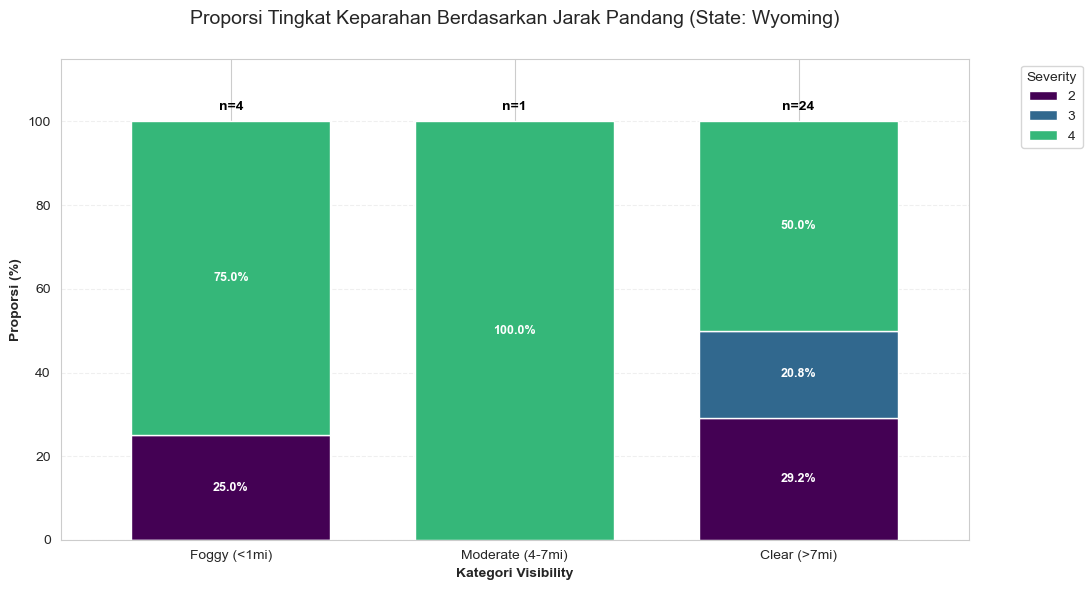

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pastikan kolom Visibility_Category sudah dibuat
vis_bins = [0, 1.0, 4.0, 7.0, 11.0] 
vis_labels = ['Foggy (<1mi)', 'Poor (1-4mi)', 'Moderate (4-7mi)', 'Clear (>7mi)']
df['Visibility_Category'] = pd.cut(df['Visibility(mi)'], bins=vis_bins, labels=vis_labels, include_lowest=True)

# 2. Filter data khusus untuk state Wyoming
df_wyoming = df[df['State'] == 'WY'].copy()

# --- TAMBAHAN: Hitung total count per kategori ---
totals = df_wyoming['Visibility_Category'].value_counts()

# 3. Hitung proporsi (Crosstab)
cross_tab_vis = pd.crosstab(df_wyoming['Visibility_Category'], 
                            df_wyoming['Severity'], 
                            normalize='index') * 100

# Urutkan berdasarkan vis_labels agar urutannya konsisten
available_labels = [l for l in vis_labels if l in cross_tab_vis.index]
cross_tab_vis = cross_tab_vis.reindex(available_labels)
totals = totals.reindex(available_labels) # Samakan urutan total dengan bar

# 4. Plotting
colors_kustom = ['#440154', '#31688e', '#35b779'] 

ax = cross_tab_vis.plot(kind='bar', stacked=True, figsize=(11, 6), 
                        color=colors_kustom, width=0.7)

# --- LABEL PERSENTASE (Di dalam bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', color='white')

# --- LABEL TOTAL JUMLAH (Di atas bar) ---
for i, label in enumerate(available_labels):
    total_val = totals[label]
    if pd.notnull(total_val): # Pastikan datanya ada
        ax.text(i, 102, f'n={int(total_val)}', 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Jarak Pandang (State: Wyoming)', fontsize=14, pad=25)
plt.xlabel('Kategori Visibility', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Beri ruang ekstra di atas untuk label n
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

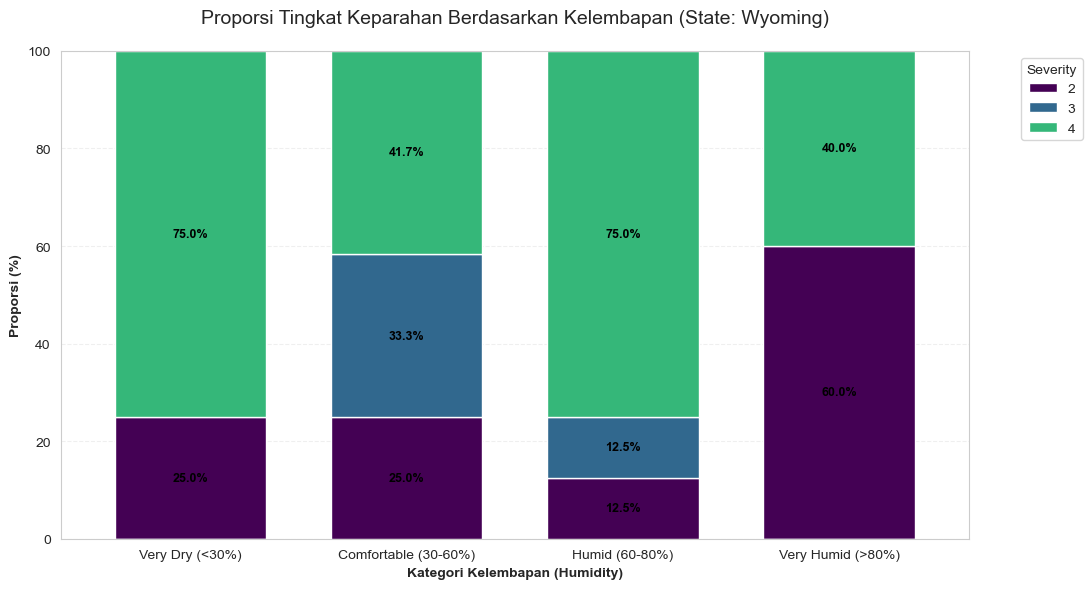

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Proses Binning Humidity (Gunakan kode yang sudah kamu buat)
hum_bins = [0, 30, 60, 80, 100] 
hum_labels = ['Very Dry (<30%)', 'Comfortable (30-60%)', 'Humid (60-80%)', 'Very Humid (>80%)']

# Pastikan nama kolom 'Humidity(%)' sesuai dengan dataset kamu
df['Humidity_Category'] = pd.cut(df['Humidity(%)'], bins=hum_bins, labels=hum_labels, include_lowest=True)

# 2. Filter data khusus untuk state Wyoming
df_wyoming = df[df['State'] == 'WY'].copy()

# 3. Hitung proporsi (Crosstab)
cross_tab_hum = pd.crosstab(df_wyoming['Humidity_Category'], 
                            df_wyoming['Severity'], 
                            normalize='index') * 100

# Urutkan berdasarkan hum_labels agar urutan di grafik logis
available_hum = [h for h in hum_labels if h in cross_tab_hum.index]
cross_tab_hum = cross_tab_hum.reindex(available_hum)

# 4. Plotting dengan warna kustom (Ungu, Biru, Hijau)
# Kode warna ini diambil agar serupa dengan gambar referensi kamu
colors_kustom = plt.cm.viridis(np.linspace(0, 1, len(cross_tab_road.columns)))

ax = cross_tab_hum.plot(kind='bar', stacked=True, figsize=(11, 6), 
                        color=colors_kustom, width=0.7)

# Menambahkan label persentase putih di tengah segmen bar
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: # Tampilkan label jika persentase > 1%
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Kelembapan (State: Wyoming)', fontsize=14, pad=20)
plt.xlabel('Kategori Kelembapan (Humidity)', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0) # Agar label bawah tidak miring
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

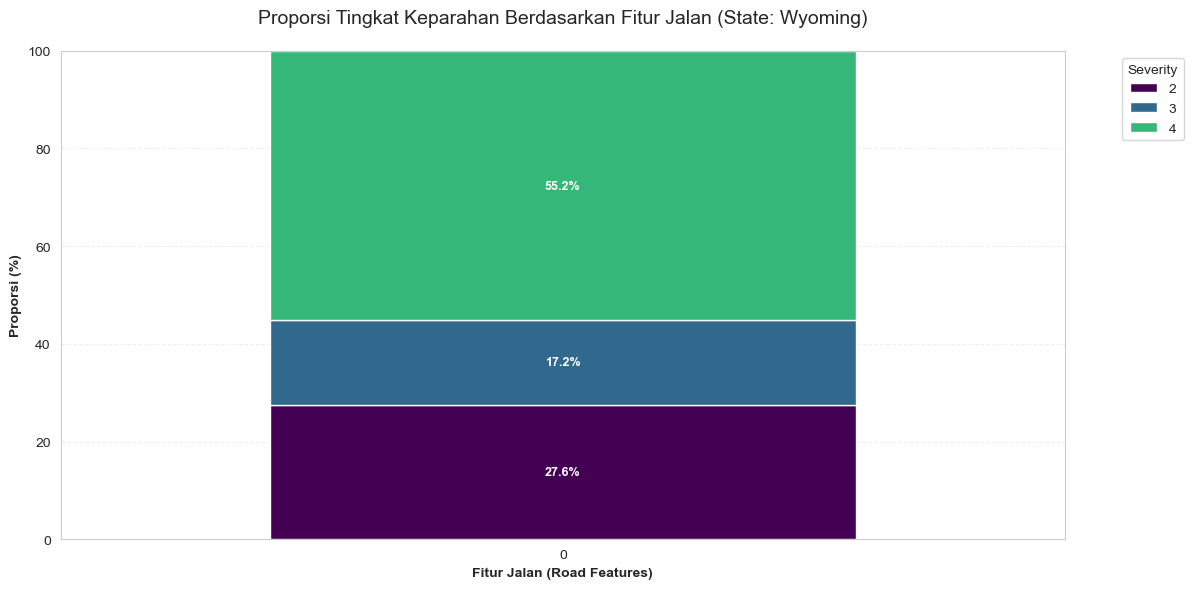

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter data khusus untuk state Wyoming
df_wyoming = df[df['State'] == 'WY'].copy()

# 2. Hitung proporsi (Crosstab) antara kolom Road Features baru dan Severity
# Pastikan nama kolomnya sesuai, di sini saya gunakan 'Road_Features'
cross_tab_road = pd.crosstab(df_wyoming['Road_Features'], 
                             df_wyoming['Severity'], 
                             normalize='index') * 100

# 3. Plotting dengan warna kustom (Ungu, Biru, Hijau) agar seragam
# Kita ambil 3 warna utama yang kamu inginkan
colors_kustom = ['#440154', '#31688e', '#35b779'] 

ax = cross_tab_road.plot(kind='bar', stacked=True, figsize=(12, 6), 
                         color=colors_kustom, width=0.7)

# Menambahkan label persentase putih di tengah setiap segmen bar
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: # Tampilkan label jika proporsi > 1% agar tidak menumpuk
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', color='white')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Fitur Jalan (State: Wyoming)', fontsize=14, pad=20)
plt.xlabel('Fitur Jalan (Road Features)', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0) # Agar label fitur jalan tetap horizontal dan mudah dibaca
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

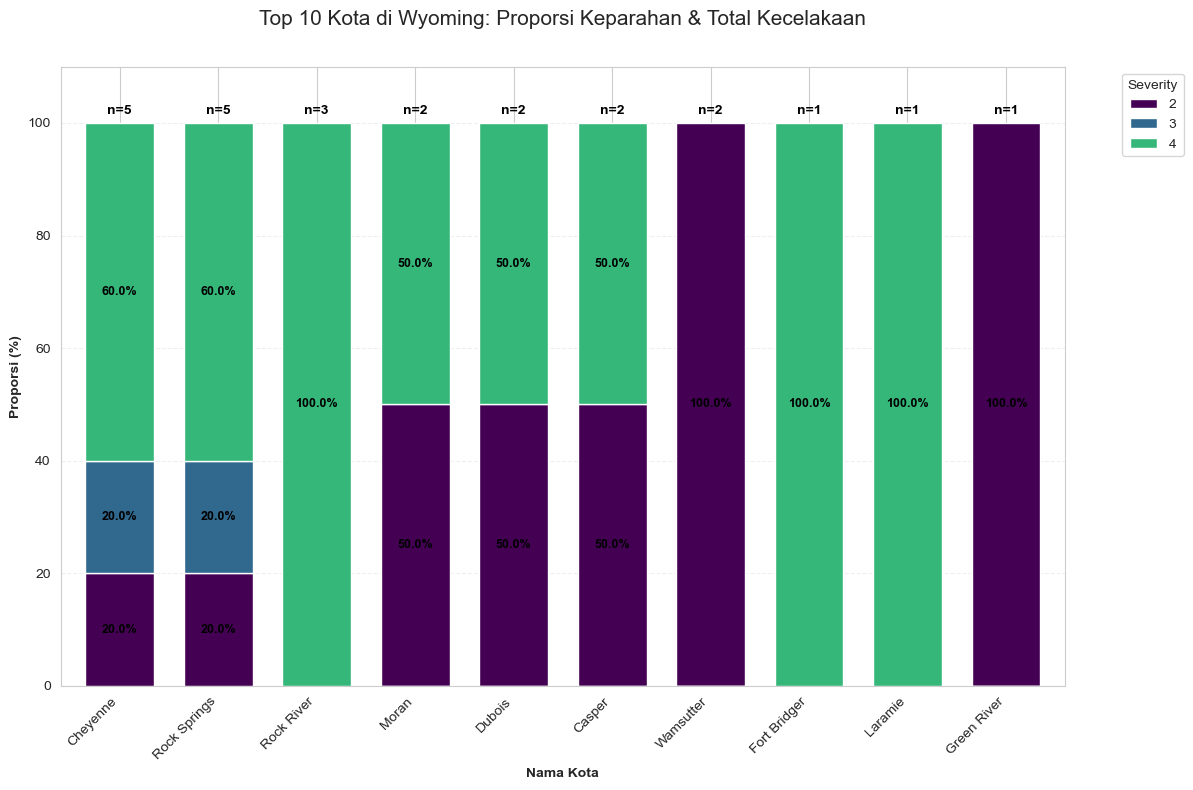

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter data untuk Wyoming
df_wyoming = df[df['State'] == 'WY'].copy()

# 2. Ambil 10 kota dengan jumlah kecelakaan terbanyak
top_10_counts = df_wyoming['City'].value_counts().nlargest(10)
top_10_cities = top_10_counts.index
df_top_cities = df_wyoming[df_wyoming['City'].isin(top_10_cities)]

# 3. Hitung proporsi Severity per kota (untuk isi bar)
city_severity = pd.crosstab(df_top_cities['City'], 
                            df_top_cities['Severity'], 
                            normalize='index') * 100

# Urutkan city_severity agar sesuai dengan urutan jumlah terbanyak (descending)
city_severity = city_severity.reindex(top_10_cities)

# 4. Plotting
colors_kustom = ['#440154', '#31688e', '#35b779'] # Ungu, Biru, Hijau

ax = city_severity.plot(kind='bar', stacked=True, figsize=(12, 8), 
                        color=colors_kustom, width=0.7)

# --- MENAMBAHKAN JUMLAH TOTAL DI ATAS BAR ---
for i, city in enumerate(top_10_cities):
    total_accidents = top_10_counts[city]
    # Koordinat x adalah index (i), koordinat y adalah 100 (karena stacked bar normalisasi sampai 100%)
    ax.text(i, 101, f'n={total_accidents}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# --- MENAMBAHKAN PERSENTASE DI DALAM BAR ---
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 3: # Tampilkan jika proporsi > 3% agar tidak tumpang tindih
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# Pengaturan Judul dan Label
plt.title('Top 10 Kota di Wyoming: Proporsi Keparahan & Total Kecelakaan', fontsize=15, pad=30)
plt.xlabel('Nama Kota', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 110) # Kasih ruang sedikit di atas untuk teks jumlah
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

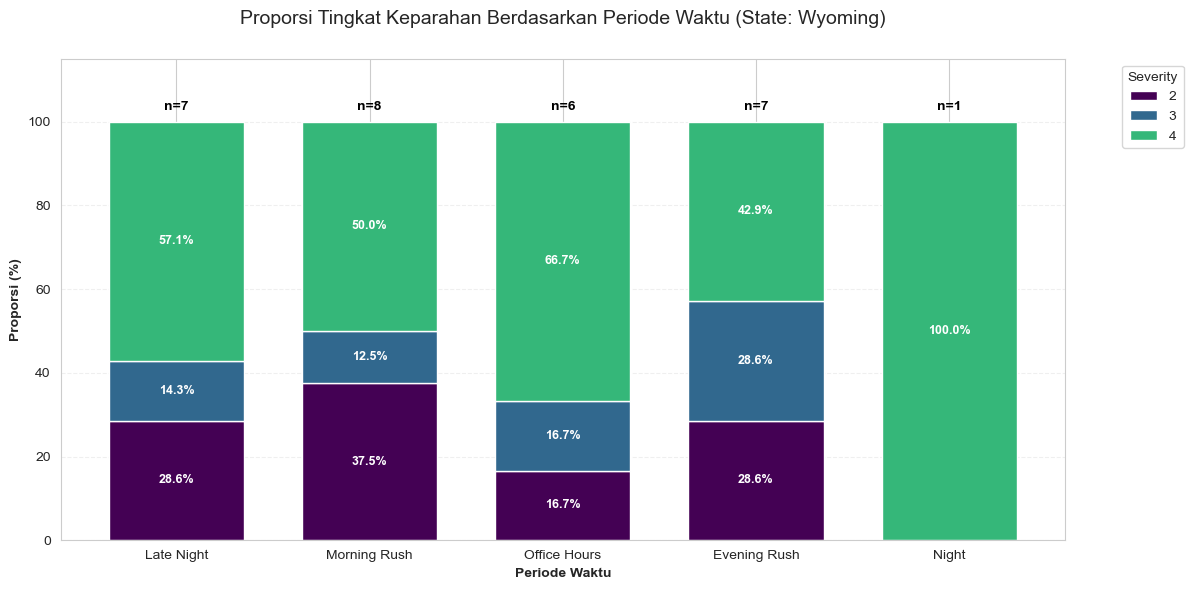

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Pastikan binning Time_Period sudah diterapkan
bins = [0, 5, 9, 15, 19, 23]
labels = ['Late Night', 'Morning Rush', 'Office Hours', 'Evening Rush', 'Night']

# Pastikan kolom 'Hour' tersedia
df['Time_Period'] = pd.cut(df['Hour'], bins=bins, labels=labels, include_lowest=True)

# 2. Filter data khusus untuk state Wyoming
df_wyoming = df[df['State'] == 'WY'].copy()

# --- TAMBAHAN: Hitung total count per periode waktu ---
totals = df_wyoming['Time_Period'].value_counts()

# 3. Hitung proporsi (Crosstab)
cross_tab_time = pd.crosstab(df_wyoming['Time_Period'], 
                             df_wyoming['Severity'], 
                             normalize='index') * 100

# Pastikan urutan bar sesuai dengan label waktu yang logis
available_periods = [l for l in labels if l in cross_tab_time.index]
cross_tab_time = cross_tab_time.reindex(available_periods)
totals = totals.reindex(available_periods) # Menyelaraskan total dengan urutan bar

# 4. Plotting
colors = ['#440154', '#31688e', '#35b779'] 
ax = cross_tab_time.plot(kind='bar', stacked=True, figsize=(12, 6), 
                         color=colors, width=0.7)

# --- LABEL PERSENTASE (Di dalam segmen bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', color='white')

# --- LABEL TOTAL JUMLAH (Di atas bar) ---
for i, period in enumerate(available_periods):
    val = totals[period]
    if pd.notnull(val):
        ax.text(i, 102, f'n={int(val)}', 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Periode Waktu (State: Wyoming)', fontsize=14, pad=25)
plt.xlabel('Periode Waktu', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0) 
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Memberi ruang agar label 'n=' tidak terpotong
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

--- Distribusi Angka Astronomical Twilight ---
True: 860167 kejadian (72.96%)
False: 318746 kejadian (27.04%)


<Figure size 1000x600 with 0 Axes>

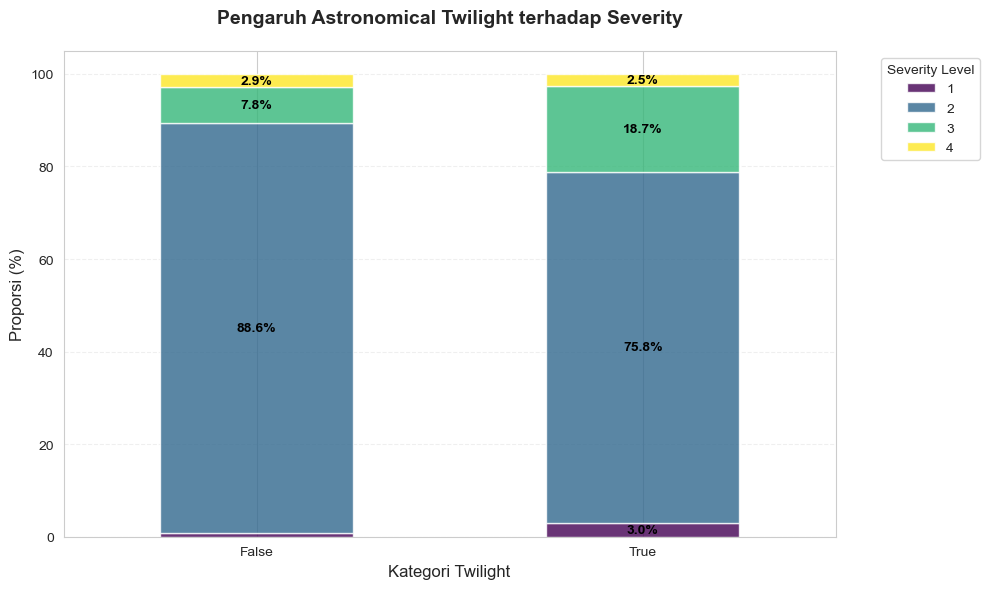

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cek Angka Eksak (Value Counts)
print("--- Distribusi Angka Astronomical Twilight ---")
counts = df['Astronomical_Twilight'].value_counts()
percent = df['Astronomical_Twilight'].value_counts(normalize=True) * 100

for idx, val in counts.items():
    print(f"{idx}: {val} kejadian ({percent[idx]:.2f}%)")

# 2. Membuat Tabel Proporsi untuk Severity
# Menggunakan crosstab agar kita bisa melihat persentase severity di tiap kategori
ct_twilight = pd.crosstab(df['Astronomical_Twilight'], 
                          df['Severity'], 
                          normalize='index') * 100

# 3. Plotting Stacked Bar Chart
plt.figure(figsize=(10, 6))
# Warna konsisten: Severity 1 (Ungu), 2 (Biru), 3 (Hijau), 4 (Kuning)
colors_custom = plt.cm.viridis(np.linspace(0, 1, len(cross_tab_time.columns)))

ax = ct_twilight.plot(kind='bar', stacked=True, figsize=(10, 6), 
                      color=colors_custom, edgecolor='white', alpha=0.8)

# Menambahkan label persentase di dalam batang
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 2: # Tampilkan label jika > 2% agar tidak tumpang tindih
        ax.annotate(f'{height:.1f}%', 
                    (x + width/2, y + height/2), 
                    ha='center', va='center', 
                    fontsize=10, fontweight='bold', color='black')

# Estetika Grafik
plt.title("Pengaruh Astronomical Twilight terhadap Severity", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Kategori Twilight", fontsize=12)
plt.ylabel("Proporsi (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Severity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

## State Illinois

C:\Users\claire\AppData\Local\Temp\ipykernel_19388\589264015.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=il_severity_counts.index, y=il_severity_counts.values, palette='viridis')


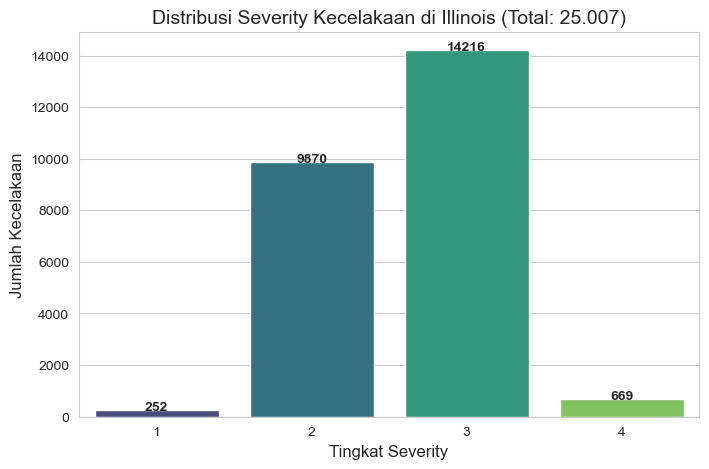

Distribusi Severity di IL:
Severity
1      252
2     9870
3    14216
4      669
Name: count, dtype: int64


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

il_data = df[df['State'] == 'IL']

il_severity_counts = il_data['Severity'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=il_severity_counts.index, y=il_severity_counts.values, palette='viridis')

plt.title('Distribusi Severity Kecelakaan di Illinois (Total: 25.007)', fontsize=14)
plt.xlabel('Tingkat Severity', fontsize=12)
plt.ylabel('Jumlah Kecelakaan', fontsize=12)

for i, v in enumerate(il_severity_counts.values):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.show()
print("Distribusi Severity di IL:")
print(il_severity_counts)

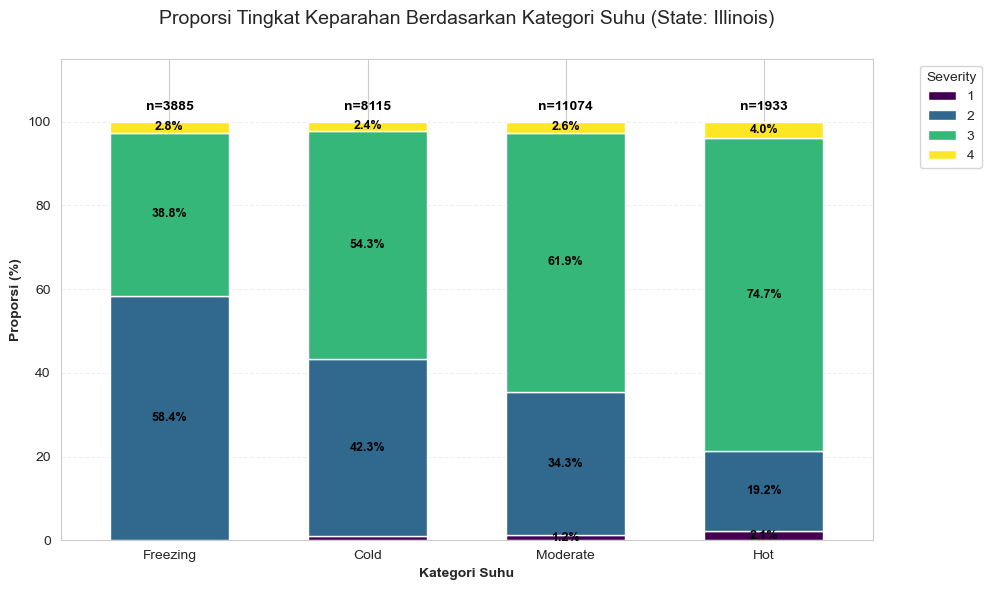

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter data khusus untuk state Illinois
df_illinois = df[df['State'] == 'IL'].copy()

# --- TAMBAHAN: Hitung total count per kategori ---
totals = df_illinois['Temp_Category'].value_counts()

# 2. Hitung proporsi (Crosstab)
cross_tab_prop = pd.crosstab(df_illinois['Temp_Category'], 
                             df_illinois['Severity'], 
                             normalize='index') * 100

# Urutkan kategori
ordered_categories = ['Freezing', 'Cold', 'Moderate', 'Hot']
available_categories = [c for c in ordered_categories if c in cross_tab_prop.index]
cross_tab_prop = cross_tab_prop.reindex(available_categories)
totals = totals.reindex(available_categories) # Sinkronkan urutan total dengan bar

# 3. Plotting
# Menggunakan warna Viridis agar konsisten dengan grafik sebelumnya
ax = cross_tab_prop.plot(kind='bar', stacked=True, figsize=(10, 6), 
                         color=['#440154', '#31688e', '#35b779', '#fde725'],
                         width=0.6)

# --- LABEL PERSENTASE (Di dalam bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', 
                color='black') # Putih biasanya lebih kontras dengan warna gelap

# --- LABEL TOTAL JUMLAH (Di atas bar) ---
for i, category in enumerate(available_categories):
    val = totals[category]
    if pd.notnull(val):
        ax.text(i, 102, f'n={int(val)}', 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Kategori Suhu (State: Illinois)', fontsize=14, pad=25)
plt.xlabel('Kategori Suhu', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Memberi ruang untuk label n=
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

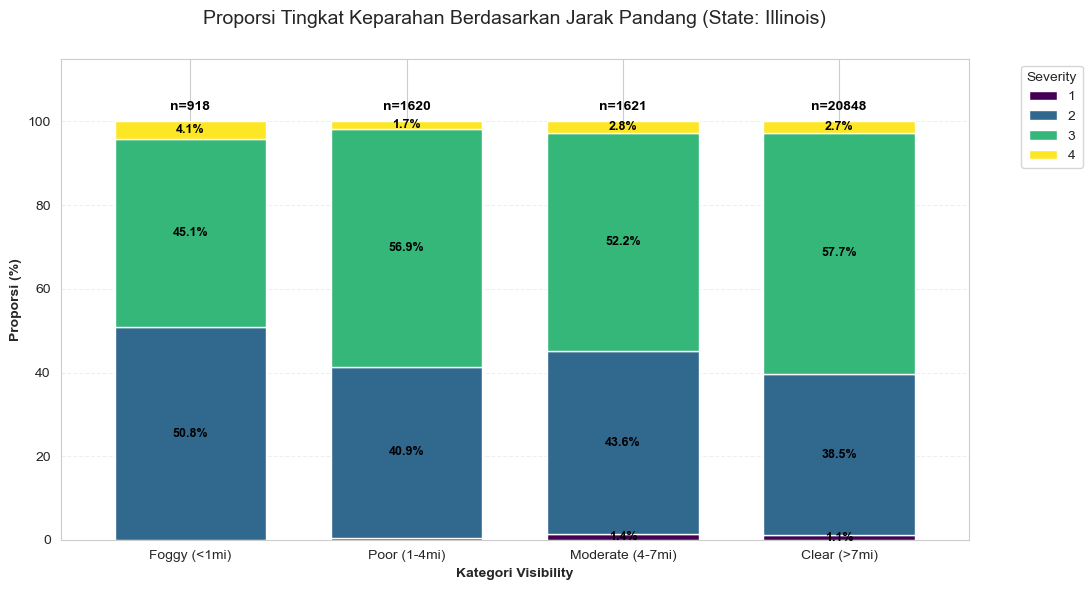

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Pastikan kolom Visibility_Category sudah dibuat
vis_bins = [0, 1.0, 4.0, 7.0, 11.0] 
vis_labels = ['Foggy (<1mi)', 'Poor (1-4mi)', 'Moderate (4-7mi)', 'Clear (>7mi)']
df['Visibility_Category'] = pd.cut(df['Visibility(mi)'], bins=vis_bins, labels=vis_labels, include_lowest=True)

# 2. Filter data khusus untuk state Illinois
df_illinois = df[df['State'] == 'IL'].copy()

# --- TAMBAHAN: Hitung total count per kategori untuk label n ---
totals = df_illinois['Visibility_Category'].value_counts()

# 3. Hitung proporsi (Crosstab)
cross_tab_vis = pd.crosstab(df_illinois['Visibility_Category'], 
                            df_illinois['Severity'], 
                            normalize='index') * 100

# Urutkan berdasarkan vis_labels agar urutannya konsisten
available_labels = [l for l in vis_labels if l in cross_tab_vis.index]
cross_tab_vis = cross_tab_vis.reindex(available_labels)
totals = totals.reindex(available_labels) # Sinkronkan urutan jumlah total

# 4. Plotting
# Menggunakan colormap viridis yang dinamis sesuai jumlah kolom severity
colors_kustom = plt.cm.viridis(np.linspace(0, 1, len(cross_tab_vis.columns)))

ax = cross_tab_vis.plot(kind='bar', stacked=True, figsize=(11, 6), 
                        color=colors_kustom, width=0.7)

# --- LABEL PERSENTASE (Di dalam segmen bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', color='black') # Warna putih agar kontras

# --- LABEL TOTAL JUMLAH (Di atas setiap bar) ---
for i, label in enumerate(available_labels):
    val = totals[label]
    if pd.notnull(val):
        ax.text(i, 102, f'n={int(val)}', 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Jarak Pandang (State: Illinois)', fontsize=14, pad=25)
plt.xlabel('Kategori Visibility', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0) 
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Memberi ruang ekstra untuk label n=
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

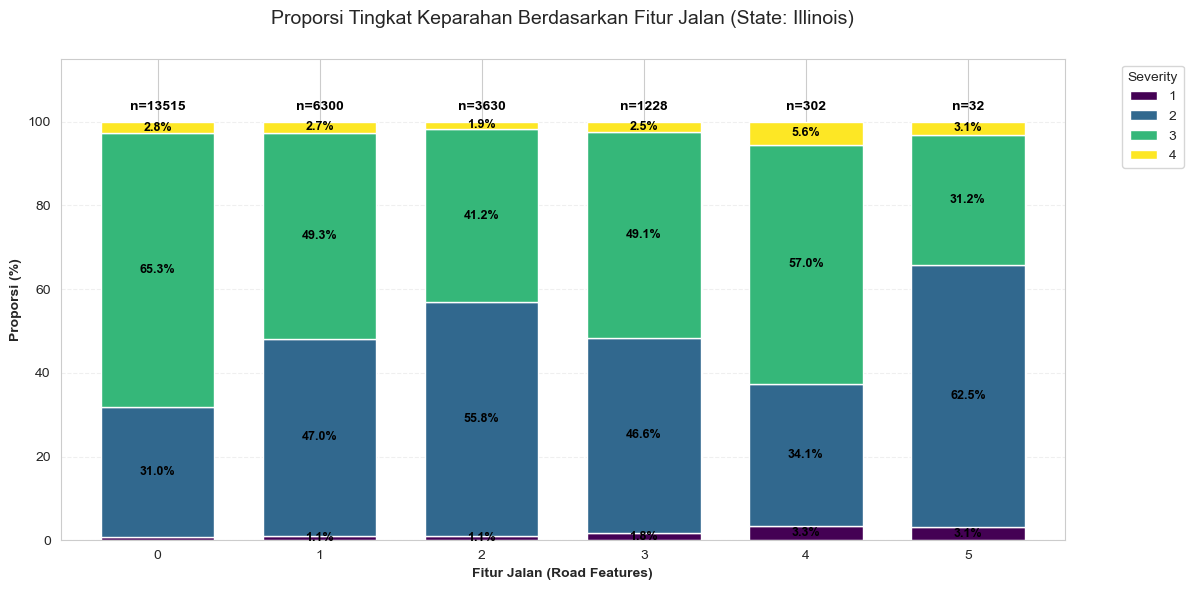

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter data khusus untuk state Illinois
df_illinois = df[df['State'] == 'IL'].copy()

# --- TAMBAHAN: Hitung total count per kategori Fitur Jalan ---
totals = df_illinois['Road_Features'].value_counts()

# 2. Hitung proporsi (Crosstab)
cross_tab_road = pd.crosstab(df_illinois['Road_Features'], 
                             df_illinois['Severity'], 
                             normalize='index') * 100

# Pastikan urutan index pada 'totals' sama dengan 'cross_tab_road'
available_features = cross_tab_road.index
totals = totals.reindex(available_features)

# 3. Plotting
# Menggunakan colormap viridis agar seragam
colors = plt.cm.viridis(np.linspace(0, 1, len(cross_tab_road.columns)))

ax = cross_tab_road.plot(kind='bar', stacked=True, figsize=(12, 6), 
                         color=colors, width=0.7)

# --- LABEL PERSENTASE (Di dalam segmen bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', color='black') # Putih agar lebih kontras

# --- LABEL TOTAL JUMLAH (Di atas setiap bar) ---
for i, feature in enumerate(available_features):
    val = totals[feature]
    if pd.notnull(val):
        ax.text(i, 102, f'n={int(val)}', 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Fitur Jalan (State: Illinois)', fontsize=14, pad=25)
plt.xlabel('Fitur Jalan (Road Features)', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0) 
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Ruang ekstra untuk label n=
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

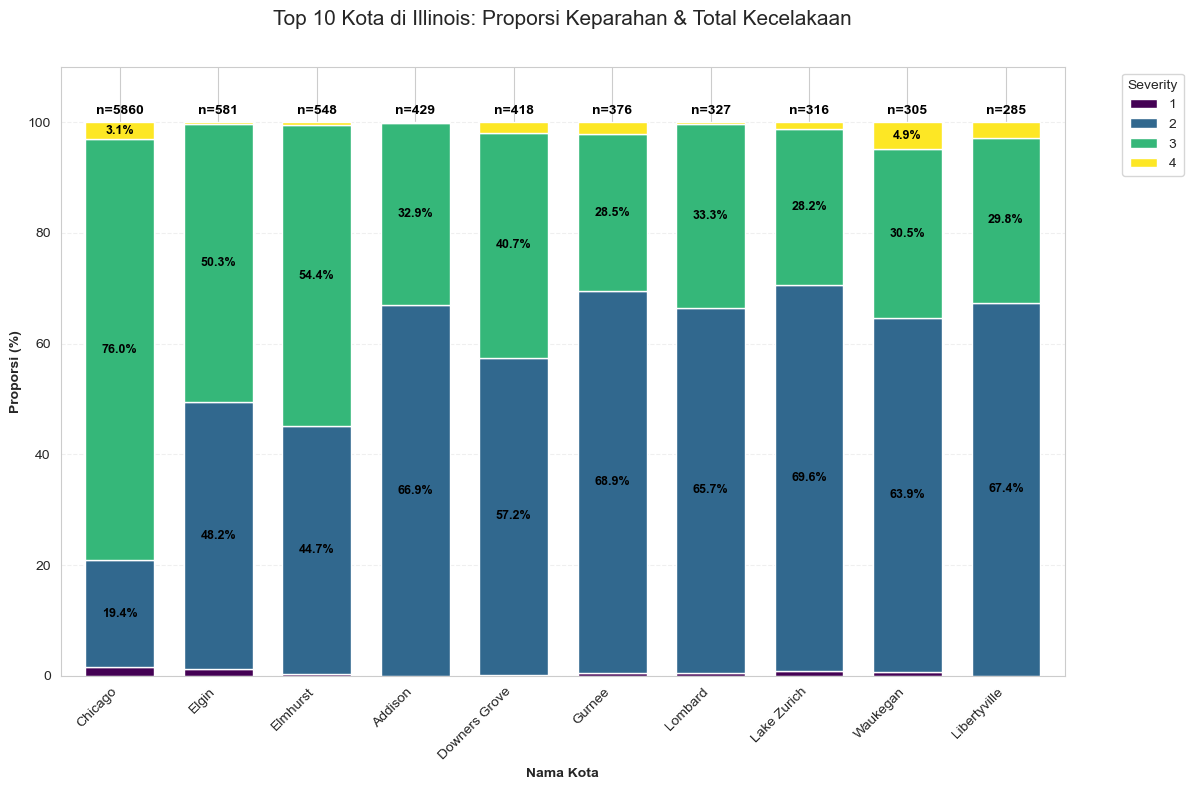

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter data untuk Wyoming
df_wyoming = df[df['State'] == 'IL'].copy()

# 2. Ambil 10 kota dengan jumlah kecelakaan terbanyak
top_10_counts = df_wyoming['City'].value_counts().nlargest(10)
top_10_cities = top_10_counts.index
df_top_cities = df_wyoming[df_wyoming['City'].isin(top_10_cities)]

# 3. Hitung proporsi Severity per kota (untuk isi bar)
city_severity = pd.crosstab(df_top_cities['City'], 
                            df_top_cities['Severity'], 
                            normalize='index') * 100

# Urutkan city_severity agar sesuai dengan urutan jumlah terbanyak (descending)
city_severity = city_severity.reindex(top_10_cities)

# 4. Plotting
colors_kustom = plt.cm.viridis(np.linspace(0, 1, len(cross_tab_road.columns)))


ax = city_severity.plot(kind='bar', stacked=True, figsize=(12, 8), 
                        color=colors_kustom, width=0.7)

# --- MENAMBAHKAN JUMLAH TOTAL DI ATAS BAR ---
for i, city in enumerate(top_10_cities):
    total_accidents = top_10_counts[city]
    # Koordinat x adalah index (i), koordinat y adalah 100 (karena stacked bar normalisasi sampai 100%)
    ax.text(i, 101, f'n={total_accidents}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# --- MENAMBAHKAN PERSENTASE DI DALAM BAR ---
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 3: # Tampilkan jika proporsi > 3% agar tidak tumpang tindih
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# Pengaturan Judul dan Label
plt.title('Top 10 Kota di Illinois: Proporsi Keparahan & Total Kecelakaan', fontsize=15, pad=30)
plt.xlabel('Nama Kota', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 110) # Kasih ruang sedikit di atas untuk teks jumlah
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

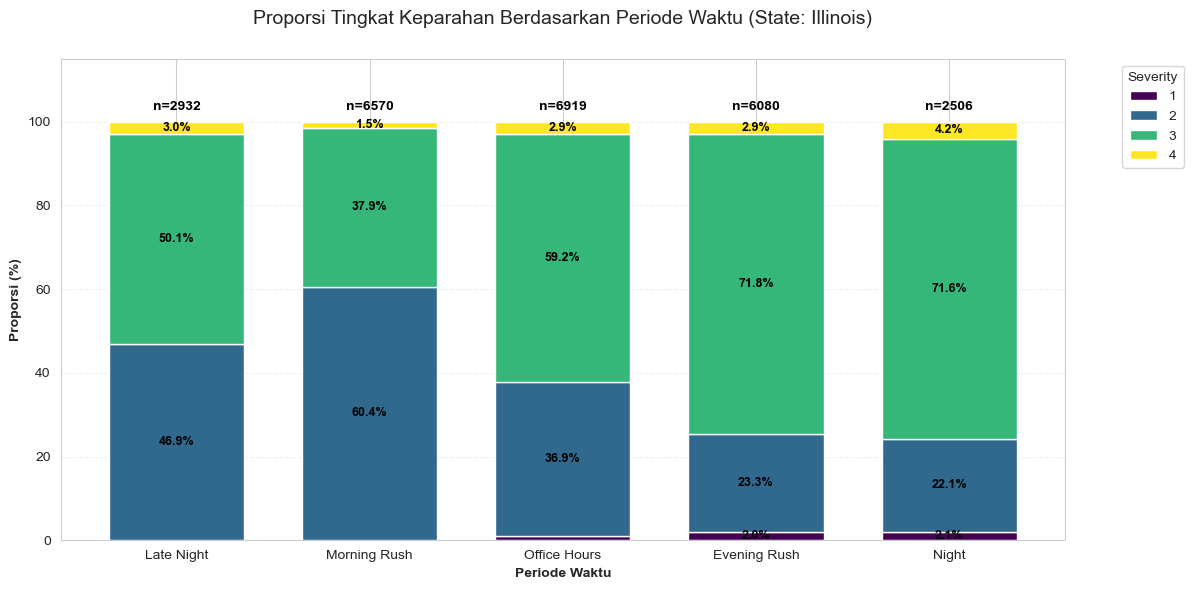

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Pastikan binning Time_Period sudah diterapkan
bins = [0, 5, 9, 15, 19, 23]
labels = ['Late Night', 'Morning Rush', 'Office Hours', 'Evening Rush', 'Night']

# Pastikan kolom 'Hour' tersedia
df['Time_Period'] = pd.cut(df['Hour'], bins=bins, labels=labels, include_lowest=True)

# 2. Filter data khusus untuk state Illinois
df_illinois = df[df['State'] == 'IL'].copy()

# --- TAMBAHAN: Hitung total count per periode waktu ---
totals = df_illinois['Time_Period'].value_counts()

# 3. Hitung proporsi (Crosstab)
cross_tab_time = pd.crosstab(df_illinois['Time_Period'], 
                             df_illinois['Severity'], 
                             normalize='index') * 100

# Pastikan urutan bar sesuai dengan label waktu yang logis
available_periods = [l for l in labels if l in cross_tab_time.index]
cross_tab_time = cross_tab_time.reindex(available_periods)
totals = totals.reindex(available_periods) # Menyelaraskan jumlah total dengan urutan bar

# 4. Plotting
colors = plt.cm.viridis(np.linspace(0, 1, len(cross_tab_time.columns)))

ax = cross_tab_time.plot(kind='bar', stacked=True, figsize=(12, 6), 
                         color=colors, width=0.7)

# --- LABEL PERSENTASE (Di dalam segmen bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', color='black') # Tetap HITAM sesuai permintaan

# --- LABEL TOTAL JUMLAH (Di atas setiap bar) ---
for i, period in enumerate(available_periods):
    val = totals[period]
    if pd.notnull(val):
        ax.text(i, 102, f'n={int(val)}', 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Periode Waktu (State: Illinois)', fontsize=14, pad=25)
plt.xlabel('Periode Waktu', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0) 
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Ruang ekstra untuk label n= agar tidak terpotong
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

## State Wisconsin

C:\Users\claire\AppData\Local\Temp\ipykernel_19388\636343547.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=il_severity_counts.index, y=il_severity_counts.values, palette='viridis')


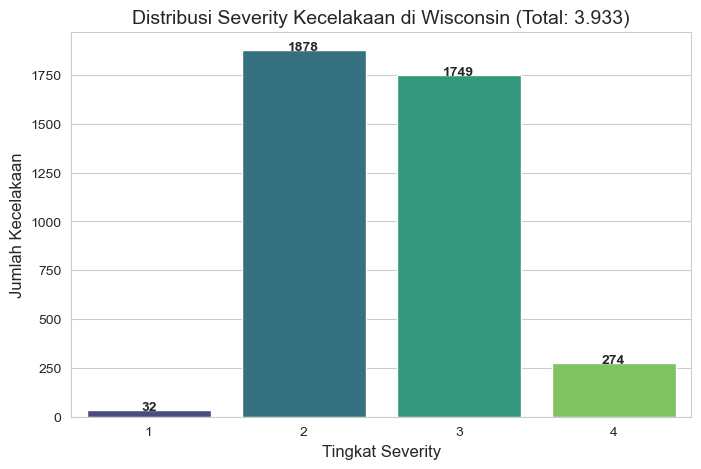

Distribusi Severity di IL:
Severity
1      32
2    1878
3    1749
4     274
Name: count, dtype: int64


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

il_data = df[df['State'] == 'WI']

il_severity_counts = il_data['Severity'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=il_severity_counts.index, y=il_severity_counts.values, palette='viridis')

plt.title('Distribusi Severity Kecelakaan di Wisconsin (Total: 3.933)', fontsize=14)
plt.xlabel('Tingkat Severity', fontsize=12)
plt.ylabel('Jumlah Kecelakaan', fontsize=12)

for i, v in enumerate(il_severity_counts.values):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.show()
print("Distribusi Severity di IL:")
print(il_severity_counts)

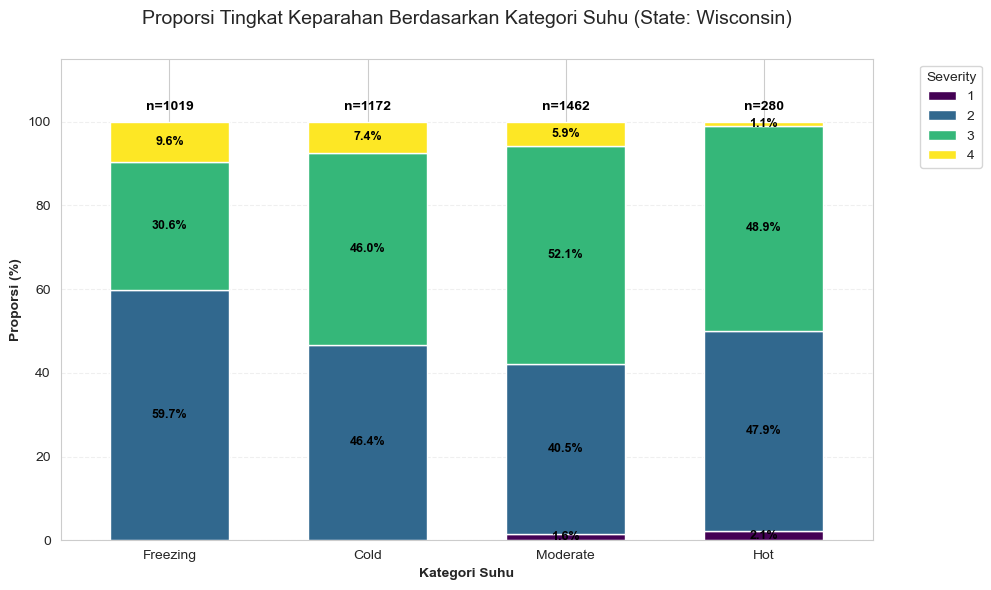

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter data khusus untuk state Wisconsin
df_wisconsin = df[df['State'] == 'WI'].copy()

# --- TAMBAHAN: Hitung total count per kategori ---
totals = df_wisconsin['Temp_Category'].value_counts()

# 2. Hitung proporsi (Crosstab)
cross_tab_prop = pd.crosstab(df_wisconsin['Temp_Category'], 
                             df_wisconsin['Severity'], 
                             normalize='index') * 100

# Urutkan kategori
ordered_categories = ['Freezing', 'Cold', 'Moderate', 'Hot']
available_categories = [c for c in ordered_categories if c in cross_tab_prop.index]
cross_tab_prop = cross_tab_prop.reindex(available_categories)
totals = totals.reindex(available_categories) # Sinkronkan urutan total dengan bar

# 3. Plotting
ax = cross_tab_prop.plot(kind='bar', stacked=True, figsize=(10, 6), 
                         color=['#440154', '#31688e', '#35b779', '#fde725'],
                         width=0.6)

# --- LABEL PERSENTASE (Di dalam bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', 
                color='black') # Tetap HITAM sesuai kode awalmu

# --- LABEL TOTAL JUMLAH (Di atas bar) ---
for i, category in enumerate(available_categories):
    val = totals[category]
    if pd.notnull(val):
        ax.text(i, 102, f'n={int(val)}', 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Kategori Suhu (State: Wisconsin)', fontsize=14, pad=25)
plt.xlabel('Kategori Suhu', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Memberi ruang agar label n= tidak terpotong
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

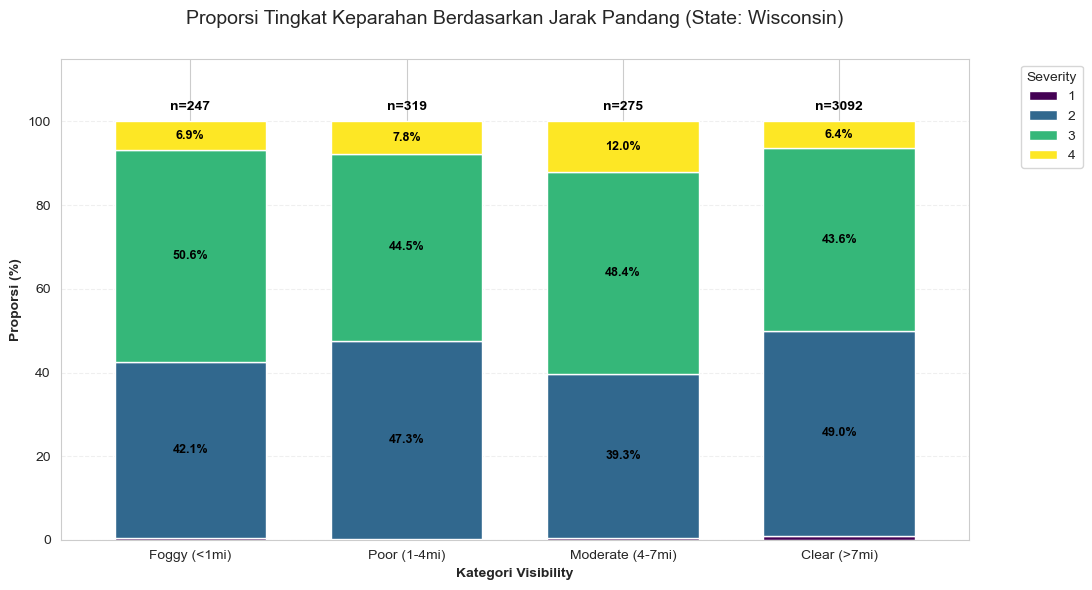

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Pastikan kolom Visibility_Category sudah dibuat
vis_bins = [0, 1.0, 4.0, 7.0, 11.0] 
vis_labels = ['Foggy (<1mi)', 'Poor (1-4mi)', 'Moderate (4-7mi)', 'Clear (>7mi)']
df['Visibility_Category'] = pd.cut(df['Visibility(mi)'], bins=vis_bins, labels=vis_labels, include_lowest=True)

# 2. Filter data khusus untuk state Wisconsin
df_wisconsin = df[df['State'] == 'WI'].copy()

# --- TAMBAHAN: Hitung total count per kategori ---
totals = df_wisconsin['Visibility_Category'].value_counts()

# 3. Hitung proporsi (Crosstab)
cross_tab_vis = pd.crosstab(df_wisconsin['Visibility_Category'], 
                            df_wisconsin['Severity'], 
                            normalize='index') * 100

# Urutkan berdasarkan vis_labels agar urutannya konsisten
available_labels = [l for l in vis_labels if l in cross_tab_vis.index]
cross_tab_vis = cross_tab_vis.reindex(available_labels)
totals = totals.reindex(available_labels) # Sinkronkan urutan total dengan bar

# 4. Plotting
# Perbaikan: Menggunakan cross_tab_vis (bukan cross_tab_road) untuk menentukan jumlah warna
colors_kustom = plt.cm.viridis(np.linspace(0, 1, len(cross_tab_vis.columns)))

ax = cross_tab_vis.plot(kind='bar', stacked=True, figsize=(11, 6), 
                        color=colors_kustom, width=0.7)

# --- LABEL PERSENTASE (Di dalam bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', color='black') # Tetap HITAM sesuai permintaan

# --- LABEL TOTAL JUMLAH (Di atas setiap bar) ---
for i, label in enumerate(available_labels):
    val = totals[label]
    if pd.notnull(val):
        ax.text(i, 102, f'n={int(val)}', 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Jarak Pandang (State: Wisconsin)', fontsize=14, pad=25)
plt.xlabel('Kategori Visibility', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0) 
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Memberi ruang ekstra untuk label n=
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

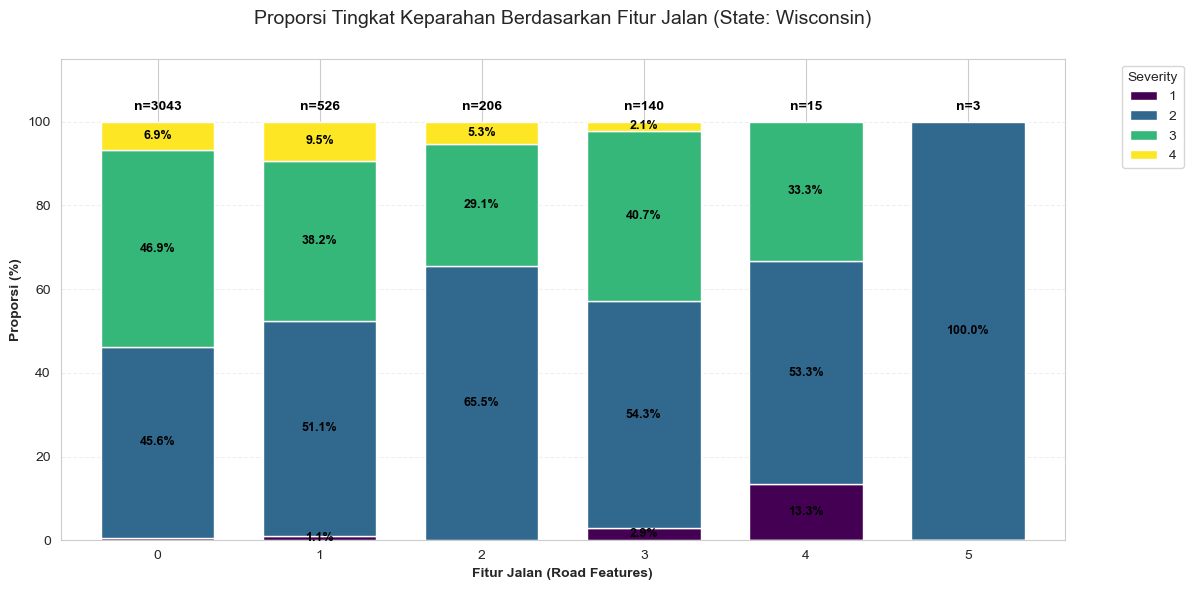

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter data khusus untuk state Wisconsin
df_wisconsin = df[df['State'] == 'WI'].copy()

# --- TAMBAHAN: Hitung total count per kategori Fitur Jalan ---
totals = df_wisconsin['Road_Features'].value_counts()

# 2. Hitung proporsi (Crosstab)
cross_tab_road = pd.crosstab(df_wisconsin['Road_Features'], 
                             df_wisconsin['Severity'], 
                             normalize='index') * 100

# Pastikan urutan indeks pada 'totals' sama dengan 'cross_tab_road'
available_features = cross_tab_road.index
totals = totals.reindex(available_features)

# 3. Plotting
# Menggunakan colormap viridis agar seragam
colors = plt.cm.viridis(np.linspace(0, 1, len(cross_tab_road.columns)))

ax = cross_tab_road.plot(kind='bar', stacked=True, figsize=(12, 6), 
                         color=colors, width=0.7)

# --- LABEL PERSENTASE (Di dalam segmen bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', color='black') # Tetap HITAM sesuai kode awal

# --- LABEL TOTAL JUMLAH (Di atas setiap bar) ---
for i, feature in enumerate(available_features):
    val = totals[feature]
    if pd.notnull(val):
        ax.text(i, 102, f'n={int(val)}', 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Fitur Jalan (State: Wisconsin)', fontsize=14, pad=25)
plt.xlabel('Fitur Jalan (Road Features)', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0) 
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Ruang ekstra untuk label n= agar tidak terpotong
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

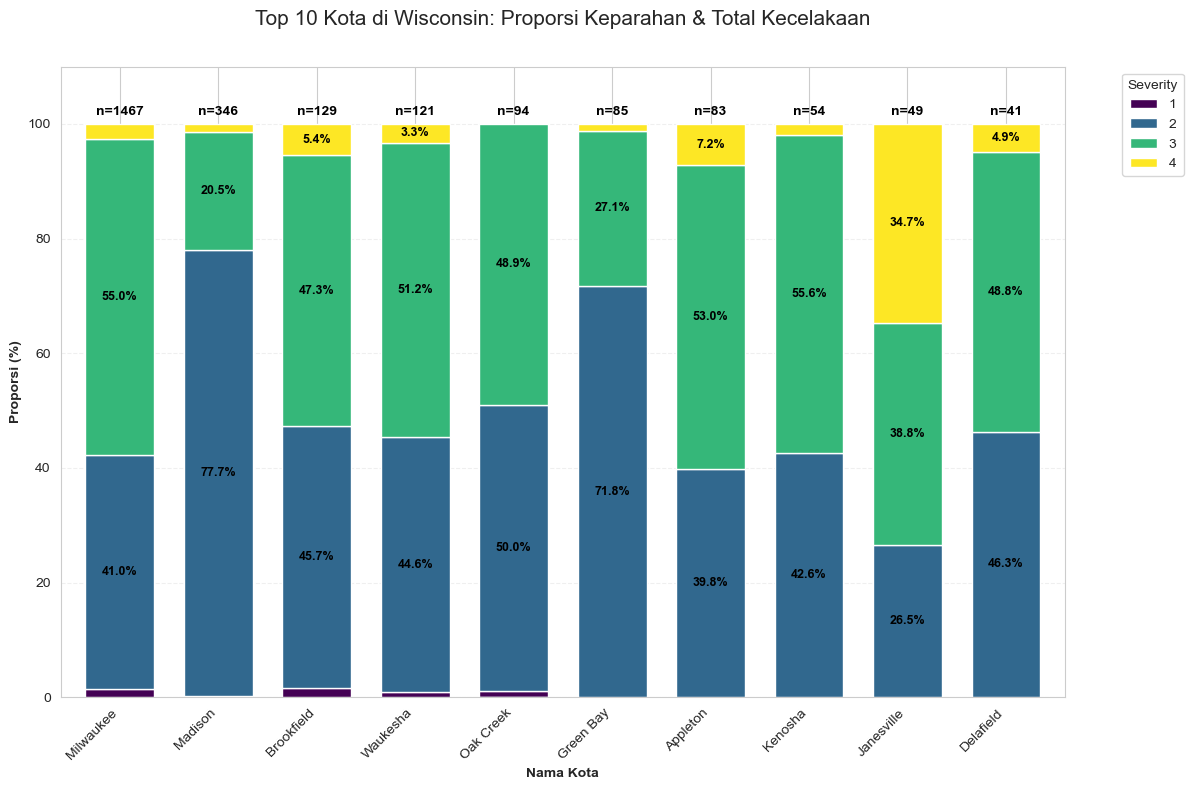

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter data untuk Wyoming
df_wyoming = df[df['State'] == 'WI'].copy()

# 2. Ambil 10 kota dengan jumlah kecelakaan terbanyak
top_10_counts = df_wyoming['City'].value_counts().nlargest(10)
top_10_cities = top_10_counts.index
df_top_cities = df_wyoming[df_wyoming['City'].isin(top_10_cities)]

# 3. Hitung proporsi Severity per kota (untuk isi bar)
city_severity = pd.crosstab(df_top_cities['City'], 
                            df_top_cities['Severity'], 
                            normalize='index') * 100

# Urutkan city_severity agar sesuai dengan urutan jumlah terbanyak (descending)
city_severity = city_severity.reindex(top_10_cities)

# 4. Plotting
colors_kustom = plt.cm.viridis(np.linspace(0, 1, len(cross_tab_road.columns)))


ax = city_severity.plot(kind='bar', stacked=True, figsize=(12, 8), 
                        color=colors_kustom, width=0.7)

# --- MENAMBAHKAN JUMLAH TOTAL DI ATAS BAR ---
for i, city in enumerate(top_10_cities):
    total_accidents = top_10_counts[city]
    # Koordinat x adalah index (i), koordinat y adalah 100 (karena stacked bar normalisasi sampai 100%)
    ax.text(i, 101, f'n={total_accidents}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# --- MENAMBAHKAN PERSENTASE DI DALAM BAR ---
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 3: # Tampilkan jika proporsi > 3% agar tidak tumpang tindih
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# Pengaturan Judul dan Label
plt.title('Top 10 Kota di Wisconsin: Proporsi Keparahan & Total Kecelakaan', fontsize=15, pad=30)
plt.xlabel('Nama Kota', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 110) # Kasih ruang sedikit di atas untuk teks jumlah
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

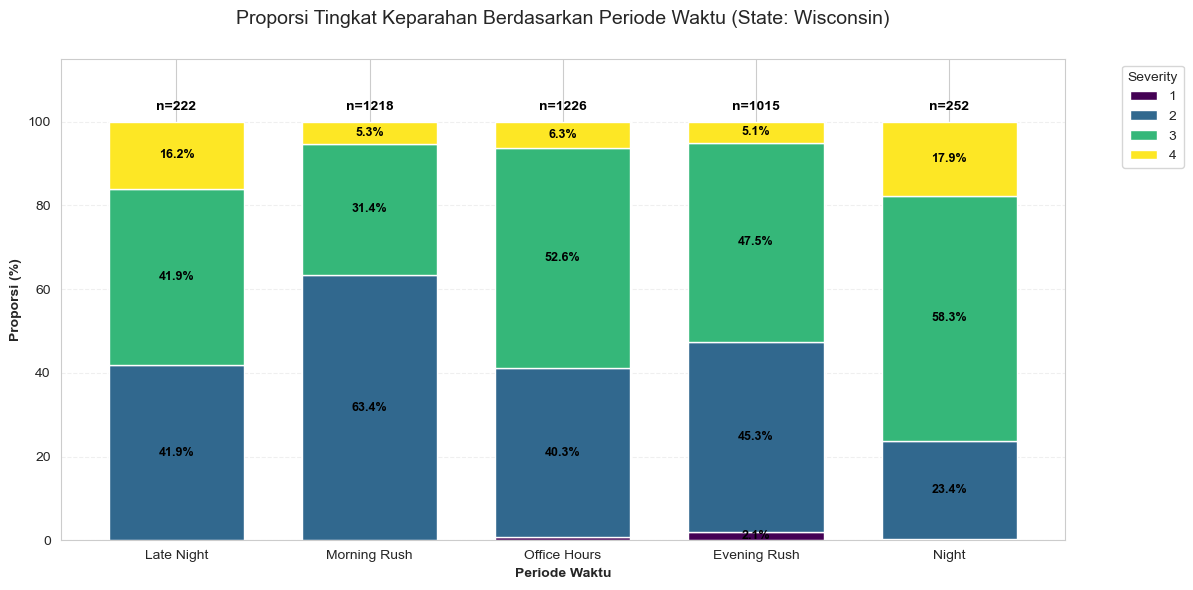

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Pastikan binning Time_Period sudah diterapkan
bins = [0, 5, 9, 15, 19, 23]
labels = ['Late Night', 'Morning Rush', 'Office Hours', 'Evening Rush', 'Night']

# Pastikan kolom 'Hour' tersedia
df['Time_Period'] = pd.cut(df['Hour'], bins=bins, labels=labels, include_lowest=True)

# 2. Filter data khusus untuk state Wisconsin
df_wisconsin = df[df['State'] == 'WI'].copy()

# --- TAMBAHAN: Hitung total count per periode waktu ---
totals = df_wisconsin['Time_Period'].value_counts()

# 3. Hitung proporsi (Crosstab)
cross_tab_time = pd.crosstab(df_wisconsin['Time_Period'], 
                             df_wisconsin['Severity'], 
                             normalize='index') * 100

# Pastikan urutan bar sesuai dengan label waktu yang logis
available_periods = [l for l in labels if l in cross_tab_time.index]
cross_tab_time = cross_tab_time.reindex(available_periods)
totals = totals.reindex(available_periods) # Sinkronkan jumlah total dengan urutan bar

# 4. Plotting
colors = plt.cm.viridis(np.linspace(0, 1, len(cross_tab_time.columns)))

ax = cross_tab_time.plot(kind='bar', stacked=True, figsize=(12, 6), 
                         color=colors, width=0.7)

# --- LABEL PERSENTASE (Di dalam segmen bar) ---
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 1: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', 
                fontsize=9, fontweight='bold', color='black') # Tetap HITAM sesuai permintaan

# --- LABEL TOTAL JUMLAH (Di atas setiap bar) ---
for i, period in enumerate(available_periods):
    val = totals[period]
    if pd.notnull(val):
        ax.text(i, 102, f'n={int(val)}', 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

# Pengaturan Judul dan Label
plt.title('Proporsi Tingkat Keparahan Berdasarkan Periode Waktu (State: Wisconsin)', fontsize=14, pad=25)
plt.xlabel('Periode Waktu', fontweight='bold')
plt.ylabel('Proporsi (%)', fontweight='bold')
plt.xticks(rotation=0) 
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115) # Memberi ruang ekstra untuk label n= agar tidak terpotong
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

# Split Data
Pakai stratified split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah Data Train: {len(X_train)}")
print(f"Jumlah Data Test: {len(X_test)}")

train_prop = y_train.value_counts(normalize=True).sort_index()
test_prop = y_test.value_counts(normalize=True).sort_index()

report = pd.DataFrame({
    'Train (%)': train_prop * 100,
    'Test (%)': test_prop * 100
})
print(report)

Jumlah Data Train: 943130
Jumlah Data Test: 235783
          Train (%)   Test (%)
Severity                      
1          2.406561   2.406450
2         79.235948  79.235992
3         15.722223  15.722508
4          2.635268   2.635050


# Target Encoding

In [21]:
!pip install category_encoders

In [22]:
from category_encoders import TargetEncoder

target_cols = ['City', 'County', 'State']

encoder = TargetEncoder(cols=target_cols, smoothing=10.0)

X_train[target_cols] = encoder.fit_transform(X_train[target_cols], y_train)
X_test[target_cols] = encoder.transform(X_test[target_cols])

# Modeling Tanpa Tuning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 37 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   Severity               1178913 non-null  category
 1   Distance(mi)           1178913 non-null  float64 
 2   City                   1178913 non-null  category
 3   County                 1178913 non-null  category
 4   State                  1178913 non-null  category
 5   Temperature(F)         1178913 non-null  float64 
 6   Humidity(%)            1178913 non-null  float64 
 7   Pressure(in)           1178913 non-null  float64 
 8   Visibility(mi)         1178913 non-null  float64 
 9   Wind_Direction         1178913 non-null  category
 10  Wind_Speed(mph)        1178913 non-null  float64 
 11  Precipitation(in)      1178913 non-null  float64 
 12  Weather_Condition      1178913 non-null  category
 13  Amenity                1178913 non-null  bool    
 14  Bu

## Light GBM
Tipe datanya harus diubah ke category

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.4f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.626607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1897
[LightGBM] [Info] Number of data points in the train set: 943130, number of used features: 35
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Accuracy: 72.1532%

Classification Report:
              precision    recall  f1-score   support

           1       0.33      0.93      0.49      5674
           2       0.97      0.72      0.82    186825
           3       0.49      0.71      0.58     37071
           4       0.17      0.76      0.28      6213

    accuracy                           0.72    235783
   macro avg       0.49      0.78      0.54    235783
weighte

## Feature Selection

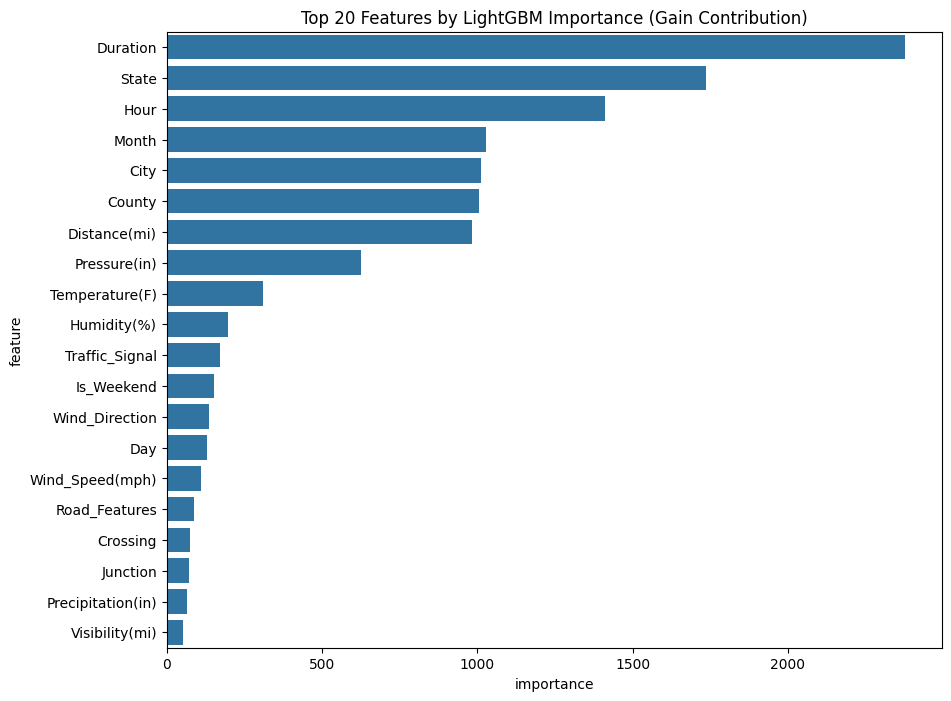

In [ ]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

In [ ]:
importance_df['importance_pct'] = (importance_df['importance'] / importance_df['importance'].sum()) * 100

importance_df = importance_df.sort_values(by='importance_pct', ascending=False).reset_index(drop=True)

print("--- Feature Importance dalam Persentase (%) ---")
print(importance_df[['feature', 'importance_pct']].tail(20))


--- Feature Importance dalam Persentase (%) ---
                  feature  importance_pct
16               Crossing        0.633333
17               Junction        0.608333
18      Precipitation(in)        0.533333
19         Visibility(mi)        0.433333
20                   Stop        0.350000
21                Station        0.325000
22      Duration_Category        0.316667
23            Time_Period        0.266667
24      Weather_Condition        0.233333
25                Amenity        0.183333
26  Astronomical_Twilight        0.158333
27                Railway        0.125000
28        Traffic_Calming        0.083333
29      Distance_Category        0.075000
30               Give_Way        0.050000
31                No_Exit        0.008333
32             Roundabout        0.000000
33                   Bump        0.000000
34       Is_Precipitating        0.000000
35          Temp_Category        0.000000


## CatBoost
Bisa menerima kategorikal asal didaftarkan di cat_features

In [ ]:
# !pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [ ]:
# from catboost import CatBoostClassifier
# from sklearn.metrics import classification_report, accuracy_score

# cat_features = ['Wind_Direction', 'Weather_Condition', 'Time_Period', 'Temp_Category',
#                 'Distance_Category', 'Duration_Category', 'Month', 'Day', 'Hour',
#                 'Road_Features']

# model_cat = CatBoostClassifier(
#     iterations=500,
#     learning_rate=0.1,
#     depth=6,
#     loss_function='MultiClass',
#     auto_class_weights='Balanced',
#     random_seed=42,
#     verbose=100,
#     thread_count=-1
# )

# model_cat.fit(
#     X_train, y_train,
#     cat_features=cat_features,
#     eval_set=(X_test, y_test),
#     early_stopping_rounds=50
# )

# y_pred_cat = model_cat.predict(X_test)

# print(f"Accuracy Total: {accuracy_score(y_test, y_pred_cat):.4f}")
# print("\nClassification Report (Balanced):")
# print(classification_report(y_test, y_pred_cat))

0:	learn: 1.2870419	test: 1.2882743	best: 1.2882743 (0)	total: 18.8s	remaining: 2h 36m 19s
100:	learn: 0.6689149	test: 0.6838038	best: 0.6838038 (100)	total: 31m 55s	remaining: 2h 6m 7s
200:	learn: 0.6029631	test: 0.6214344	best: 0.6214344 (200)	total: 1h 2m 58s	remaining: 1h 33m 40s
300:	learn: 0.5732005	test: 0.5949522	best: 0.5949522 (300)	total: 1h 34m 25s	remaining: 1h 2m 25s
400:	learn: 0.5543613	test: 0.5797508	best: 0.5797508 (400)	total: 2h 6m 3s	remaining: 31m 7s
499:	learn: 0.5409262	test: 0.5690593	best: 0.5690593 (499)	total: 2h 37m 1s	remaining: 0us

bestTest = 0.5690592646
bestIteration = 499

Accuracy Total: 0.7151

Classification Report (Balanced):
              precision    recall  f1-score   support

           1       0.32      0.93      0.47      5674
           2       0.97      0.71      0.82    186825
           3       0.48      0.71      0.57     37071
           4       0.17      0.76      0.28      6213

    accuracy                           0.72    235783


## Feature Selection

In [ ]:
# importances = model_cat.get_feature_importance()
# feature_names = X_train.columns

# importance_df = pd.DataFrame({
#     'feature': feature_names,
#     'importance': importances
# })


# importance_df['importance_pct'] = (importance_df['importance'] / importance_df['importance'].sum()) * 100


# importance_df = importance_df.sort_values(by='importance_pct', ascending=False).reset_index(drop=True)


# print("--- CatBoost Feature Importance (%) ---")
# print(importance_df[['feature', 'importance_pct']].head(20))


# plt.figure(figsize=(10, 8))
# sns.barplot(x='importance_pct', y='feature', data=importance_df.head(20), palette='viridis')
# plt.title('Top 20 Features by CatBoost Importance (%)')
# plt.xlabel('Contribution Percentage (%)')
# plt.ylabel('Features')
# plt.show()

In [ ]:
# print("--- CatBoost Feature Importance (%) ---")
# print(importance_df[['feature', 'importance_pct']].tail(20))

## Random Forest
Kategorikal wajib di encode

In [17]:
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
y_train_rf = y_train.copy()
y_test_rf = y_test.copy()

ohe_targets = [
    'Wind_Direction', 'Weather_Condition', 'Time_Period',
    'Temp_Category', 'Distance_Category', 'Duration_Category'
]

X_train_rf = pd.get_dummies(X_train_rf, columns=ohe_targets, drop_first=True, dtype=int)

X_test_rf = pd.get_dummies(X_test_rf, columns=ohe_targets, drop_first=True, dtype=int)
X_test_rf = X_test_rf.reindex(columns=X_train_rf.columns, fill_value=0)
print(f"Dimensi X_train_rf: {X_train_rf.shape}")
print(f"Dimensi X_test_rf : {X_test_rf.shape}")


Dimensi X_train_rf: (943130, 57)
Dimensi X_test_rf : (235783, 57)


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    max_samples=0.5,
    min_samples_leaf=5
)

rf_model.fit(X_train_rf, y_train_rf)

y_pred = rf_model.predict(X_test_rf)

print("\n✅ Classification Report:")
print(classification_report(y_test_rf, y_pred, zero_division=0))

acc = accuracy_score(y_test_rf, y_pred)
print(f"🚀 Accuracy Total: {acc:.4f}")


✅ Classification Report:
              precision    recall  f1-score   support

           1       0.52      0.82      0.64      5674
           2       0.94      0.86      0.90    186825
           3       0.56      0.72      0.63     37071
           4       0.42      0.56      0.48      6213

    accuracy                           0.83    235783
   macro avg       0.61      0.74      0.66    235783
weighted avg       0.86      0.83      0.84    235783

🚀 Accuracy Total: 0.8313


In [20]:
y_pred = rf_model.predict(X_train_rf)

print("\n✅ Classification Report (Train):")
print(classification_report(y_train_rf, y_pred, zero_division=0))

acc = accuracy_score(y_train_rf, y_pred)
print(f"🚀 Accuracy Total: {acc:.4f}")


✅ Classification Report:
              precision    recall  f1-score   support

           1       0.60      0.96      0.74     22697
           2       0.97      0.88      0.92    747298
           3       0.64      0.84      0.73    148281
           4       0.58      0.84      0.69     24854

    accuracy                           0.87    943130
   macro avg       0.70      0.88      0.77    943130
weighted avg       0.90      0.87      0.88    943130

🚀 Accuracy Total: 0.8729


## Feature Selection

In [ ]:
feature_names = X_train_rf.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.tail(20))

                              Feature  Importance
47                  Time_Period_Night    0.003421
32                  Wind_Direction_NE    0.003152
29                   Is_Precipitating    0.003147
19                               Stop    0.002424
39              Weather_Condition_fog    0.002025
18                            Station    0.001637
53   Distance_Category_Extreme Impact    0.001489
43     Weather_Condition_thunderstorm    0.001334
42             Weather_Condition_snow    0.000952
10                            Amenity    0.000890
16                            Railway    0.000872
13                           Give_Way    0.000683
54  Duration_Category_Medium (12-24h)    0.000620
56   Duration_Category_Extreme (>36h)    0.000416
15                            No_Exit    0.000290
20                    Traffic_Calming    0.000188
55    Duration_Category_Long (24-36h)    0.000163
11                               Bump    0.000069
40             Weather_Condition_hail    0.000016


In [ ]:
print(feature_importance_df.head(20))

                  Feature  Importance
23               Duration    0.124203
1                    City    0.114564
2                  County    0.087252
25                  Month    0.072234
6            Pressure(in)    0.065123
0            Distance(mi)    0.063251
3                   State    0.061403
5             Humidity(%)    0.054966
4          Temperature(F)    0.053588
24                   Hour    0.047386
8         Wind_Speed(mph)    0.040057
26                    Day    0.032353
7          Visibility(mi)    0.013961
27          Road_Features    0.011646
21         Traffic_Signal    0.010357
22  Astronomical_Twilight    0.008194
34       Wind_Direction_S    0.007862
38       Wind_Direction_W    0.007462
9       Precipitation(in)    0.007188
28             Is_Weekend    0.007030


## Coba Light GBM di Data OHE

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_rf, y_train_rf)

y_pred = model.predict(X_test_rf)

print(f"Accuracy: {accuracy_score(y_test_rf, y_pred)*100:.4f}%")
print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.446614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1917
[LightGBM] [Info] Number of data points in the train set: 943130, number of used features: 56
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Accuracy: 72.1057%

Classification Report:
              precision    recall  f1-score   support

           1       0.34      0.93      0.49      5674
           2       0.97      0.72      0.82    186825
           3       0.49      0.71      0.58     37071
           4       0.17      0.76      0.28      6213

    accuracy                       

# Hasil Feature Selection

In [ ]:
columns_to_drop = ['Roundabout', 'Bump', 'No_Exit', 'Traffic_Calming', 'Give_Way', 'Railway', 'Amenity']

X_train = X_train.drop(columns_to_drop, axis=1)
X_test = X_test.drop(columns_to_drop, axis=1)

# Modeling Tanpa Tuning After Feature Selection

## LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.4f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.725560 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1885
[LightGBM] [Info] Number of data points in the train set: 943130, number of used features: 29
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Accuracy: 72.1189%

Classification Report:
              precision    recall  f1-score   support

           1       0.34      0.93      0.49      5674
           2       0.97      0.72      0.82    186825
           3       0.49      0.71      0.58     37071
           4       0.17      0.76      0.28      6213

    accuracy                           0.72    235783
   macro avg       0.49      0.78      0.54    235783
weighted avg       0.85      0.72      0.76    235783



## XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_train_shifted = y_train.astype(int) - 1
y_test_shifted = y_test.astype(int) - 1

model_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    tree_method='hist',
    enable_categorical=True,
    random_state=42
)

print("Memulai proses training...")
model_xgb.fit(X_train, y_train_shifted)

y_pred_shifted = model_xgb.predict(X_test)


y_pred = y_pred_shifted + 1

y_test_int = y_test.astype(int)

print("\n=== Laporan Klasifikasi XGBoost ===")
print(classification_report(y_test_int, y_pred))
print(f"Accuracy Score: {accuracy_score(y_test_int, y_pred):.4f}")

Memulai proses training...

=== Laporan Klasifikasi XGBoost ===
              precision    recall  f1-score   support

           1       0.73      0.65      0.69      5674
           2       0.89      0.95      0.92    186825
           3       0.69      0.53      0.60     37071
           4       0.64      0.29      0.40      6213

    accuracy                           0.86    235783
   macro avg       0.74      0.61      0.65    235783
weighted avg       0.85      0.86      0.85    235783

Accuracy Score: 0.8633


## Feature Selection

In [ ]:
importance_type = 'gain'
importance_scores = model_xgb.get_booster().get_score(importance_type=importance_type)

fi_df = pd.DataFrame({
    'Feature': list(importance_scores.keys()),
    'Importance': list(importance_scores.values())
})

fi_df = fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)


print("\nTabel 10 Feature Importance Terbawah")
print(fi_df.tail(10).to_markdown(index=False))


Tabel 10 Feature Importance Terbawah
| Feature           |   Importance |
|:------------------|-------------:|
| Temperature(F)    |      9.00929 |
| Distance_Category |      8.45339 |
| Precipitation(in) |      7.46373 |
| Humidity(%)       |      5.23947 |
| Wind_Direction    |      4.91191 |
| Wind_Speed(mph)   |      4.27393 |
| Temp_Category     |      4.26683 |
| Visibility(mi)    |      4.04875 |
| Is_Weekend        |      3.43628 |
| Time_Period       |      3.38498 |


## Random Forest

In [ ]:
columns_to_drop = ['Roundabout', 'Bump', 'No_Exit', 'Traffic_Calming', 'Give_Way', 'Railway', 'Amenity']

X_train_rf = X_train_rf.drop(columns_to_drop, axis=1, errors='ignore')
X_test_rf = X_test_rf.drop(columns_to_drop, axis=1, errors='ignore')

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    max_samples=0.5,
    min_samples_leaf=5
)

rf_model.fit(X_train_rf, y_train_rf)

y_pred = rf_model.predict(X_test_rf)

print("\n✅ Classification Report:")
print(classification_report(y_test_rf, y_pred, zero_division=0))


acc = accuracy_score(y_test_rf, y_pred)
print(f"🚀 Accuracy Total: {acc:.4f}")


✅ Classification Report:
              precision    recall  f1-score   support

           1       0.55      0.82      0.66      5674
           2       0.94      0.87      0.90    186825
           3       0.57      0.73      0.64     37071
           4       0.43      0.55      0.48      6213

    accuracy                           0.84    235783
   macro avg       0.62      0.74      0.67    235783
weighted avg       0.86      0.84      0.85    235783

🚀 Accuracy Total: 0.8373


In [ ]:
y_pred_train = rf_model.predict(X_train_rf)

print("\n📊 === Classification Report (TRAIN DATA) ===")
print(classification_report(y_train_rf, y_pred_train, zero_division=0))

acc_train = accuracy_score(y_train_rf, y_pred_train)
acc_test = accuracy_score(y_test_rf, y_pred)

print(f"🚀 Accuracy Train: {acc_train:.4f}")
print(f"🚀 Accuracy Test : {acc_test:.4f}")
print(f"🔍 Gap Akurasi   : {abs(acc_train - acc_test):.4f}")

if acc_train - acc_test > 0.10:
    print("⚠️ Peringatan: Model Anda kemungkinan Overfitting (Gap > 10%)")
else:
    print("✅ Model terlihat stabil (Good Fit)")


📊 === Classification Report (TRAIN DATA) ===
              precision    recall  f1-score   support

           1       0.62      0.96      0.76     22697
           2       0.97      0.88      0.93    747298
           3       0.65      0.85      0.74    148281
           4       0.60      0.84      0.70     24854

    accuracy                           0.88    943130
   macro avg       0.71      0.88      0.78    943130
weighted avg       0.90      0.88      0.89    943130

🚀 Accuracy Train: 0.8794
🚀 Accuracy Test : 0.8373
🔍 Gap Akurasi   : 0.0421
✅ Model terlihat stabil (Good Fit)


## Ensemble Model (LightGBM dan XGBoost)

In [21]:
from sklearn.ensemble import VotingClassifier
import xgboost as xgb
import lightgbm as lgb
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

y_train_shifted = y_train.astype(int) - 1
y_test_shifted = y_test.astype(int) - 1

model_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    tree_method='hist',
    enable_categorical=True,
    random_state=42
)

model_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', model_xgb),
        ('lgb', model_lgb)
    ],
    voting='soft'
)


print("Sedang melatih Ensemble (XGBoost + LightGBM)...")
ensemble_model.fit(X_train, y_train_shifted)


y_pred_shifted = ensemble_model.predict(X_test)


y_pred = y_pred_shifted + 1

y_test_int = y_test.astype(int)
print("\n=== Laporan Klasifikasi Ensemble Model ===")
print(classification_report(y_test_int, y_pred))
print(f"Final Accuracy Score: {accuracy_score(y_test_int, y_pred):.4f}")

Sedang melatih Ensemble (XGBoost + LightGBM)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.127226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1897
[LightGBM] [Info] Number of data points in the train set: 943130, number of used features: 35
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

=== Laporan Klasifikasi Ensemble Model ===
              precision    recall  f1-score   support

           1       0.54      0.87      0.67      5674
           2       0.93      0.89      0.91    186825
           3       0.61      0.66      0.63     37071
           4       0.37      0.53      0.43      6213

    accuracy                           0.84    235783
   macro avg

In [22]:
y_pred_shifted = ensemble_model.predict(X_train)

y_pred = y_pred_shifted + 1

y_train_int = y_train.astype(int)
print("\n=== Laporan Klasifikasi Ensemble Model (Training Set)===")
print(classification_report(y_train_int, y_pred))
print(f"Final Accuracy Score: {accuracy_score(y_train_int, y_pred):.4f}")


=== Laporan Klasifikasi Ensemble Model (Training Set)===
              precision    recall  f1-score   support

           1       0.56      0.89      0.69     22697
           2       0.94      0.89      0.91    747298
           3       0.62      0.67      0.65    148281
           4       0.40      0.60      0.48     24854

    accuracy                           0.85    943130
   macro avg       0.63      0.76      0.68    943130
weighted avg       0.86      0.85      0.85    943130

Final Accuracy Score: 0.8479


# Modeling dengan Tuning

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 4, 10],
    'max_features': ['sqrt', 'log2'],
    'max_samples': [0.5, 0.7, 0.9]
}

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)


rf_random = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1_weighted'
)

print("Memulai Tuning Random Forest (Fokus: Weighted F1)... ")
rf_random.fit(X_train_rf, y_train_rf)

best_rf = rf_random.best_estimator_
print(f"\nParameter Terbaik: {rf_random.best_params_}")

y_pred_rf = best_rf.predict(X_test_rf)

print("\n=== Laporan Klasifikasi Random Forest (Tuned - Weighted) ===")
print(classification_report(y_test_rf, y_pred_rf))
print(f"Accuracy Score: {accuracy_score(y_test_rf, y_pred_rf):.4f}")

Memulai Tuning Random Forest (Fokus: Weighted F1)... 
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Parameter Terbaik: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_samples': 0.9, 'max_features': 'log2', 'max_depth': None}

=== Laporan Klasifikasi Random Forest (Tuned - Weighted) ===
              precision    recall  f1-score   support

           1       0.55      0.82      0.66      5674
           2       0.94      0.87      0.90    186825
           3       0.57      0.73      0.64     37071
           4       0.45      0.59      0.51      6213

    accuracy                           0.84    235783
   macro avg       0.63      0.75      0.68    235783
weighted avg       0.86      0.84      0.85    235783

Accuracy Score: 0.8383


In [ ]:
y_pred_train_rf = best_rf.predict(X_train_rf)

print("\n=== Laporan Klasifikasi Random Forest (TRAIN DATA) ===")
print(classification_report(y_train_rf, y_pred_train_rf))

acc_train = accuracy_score(y_train_rf, y_pred_train_rf)
print(f"Accuracy Score (Train): {acc_train:.4f}")


=== Laporan Klasifikasi Random Forest (TRAIN DATA) ===
              precision    recall  f1-score   support

           1       0.65      0.99      0.78     22697
           2       0.99      0.89      0.94    747298
           3       0.69      0.91      0.78    148281
           4       0.67      0.97      0.79     24854

    accuracy                           0.90    943130
   macro avg       0.75      0.94      0.82    943130
weighted avg       0.92      0.90      0.91    943130

Accuracy Score (Train): 0.8993


### Feature Importance

/tmp/ipykernel_15855/1807745044.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


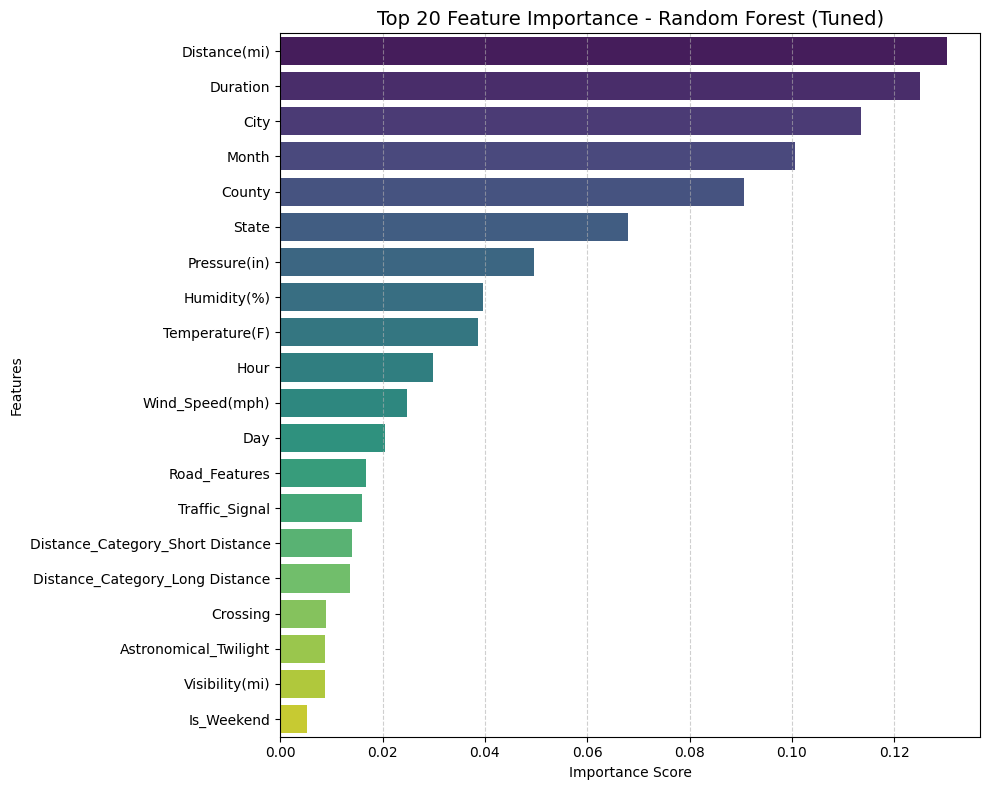


Top 10 Fitur Paling Berpengaruh:
       Feature  Importance
  Distance(mi)    0.130240
      Duration    0.124947
          City    0.113537
         Month    0.100620
        County    0.090716
         State    0.067909
  Pressure(in)    0.049611
   Humidity(%)    0.039596
Temperature(F)    0.038584
          Hour    0.029800


In [ ]:
importances = best_rf.feature_importances_
feature_names = X_train_rf.columns

rf_feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

rf_feat_importance = rf_feat_importance.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=rf_feat_importance,
    palette='viridis'
)

plt.title('Top 20 Feature Importance - Random Forest (Tuned)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nTop 10 Fitur Paling Berpengaruh:")
print(rf_feat_importance.head(10).to_string(index=False))

## Ensemble Model

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, make_scorer

X_tune = X_train.sample(n=100000, random_state=42)
y_tune = y_train_shifted.loc[X_tune.index]

param_dist = {
    'xgb__max_depth': [3, 6, 9],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 1.0],

    'lgb__num_leaves': [31, 64, 127],
    'lgb__learning_rate': [0.01, 0.05, 0.1],
    'lgb__min_child_samples': [20, 50, 100],

    'weights': [[1, 1], [1, 1.5], [1.5, 1]]
}


random_search = RandomizedSearchCV(
    estimator=ensemble_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_macro',
    cv=3,
    verbose=3,
    random_state=42,
    n_jobs=-1
)

print("Memulai Hyperparameter Tuning pada Ensemble...")
random_search.fit(X_tune, y_tune)

best_ensemble = random_search.best_estimator_
print(f"\nParameter Terbaik: {random_search.best_params_}")

print("\nMelatih Model Terbaik pada seluruh dataset...")
best_ensemble.fit(X_train, y_train_shifted)

y_pred_final = best_ensemble.predict(X_test) + 1
print("\n=== Laporan Klasifikasi Ensemble (Tuned) ===")
print(classification_report(y_test_int, y_pred_final))

Memulai Hyperparameter Tuning pada Ensemble...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022523 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1845
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 29
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

Parameter Terbaik: {'xgb__subsample': 0.7, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.1, 'weights': [1, 1], 'lgb__num_leaves': 127, 'lgb__min_child_samples': 20, 'lgb__learning_rate': 0.1}

Melatih Model Terbaik pada seluruh dataset...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing w

In [ ]:
print(f"Accuracy Score: {accuracy_score(y_test_int, y_pred):.4f}")

Accuracy Score: 0.8426


In [ ]:
y_pred_train_final = best_ensemble.predict(X_train) + 1

y_train_int = y_train_shifted + 1

print("\n📊 === Laporan Klasifikasi Ensemble (TRAIN DATA) ===")
print(classification_report(y_train_int, y_pred_train_final, zero_division=0))

f1_train = f1_score(y_train_int, y_pred_train_final, average='macro')
f1_test = f1_score(y_test_int, y_pred_final, average='macro')

print(f"🚀 F1-Macro (Train): {f1_train:.4f}")
print(f"🚀 F1-Macro (Test) : {f1_test:.4f}")
print(f"🔍 Selisih (Gap)   : {abs(f1_train - f1_test):.4f}")


📊 === Laporan Klasifikasi Ensemble (TRAIN DATA) ===
              precision    recall  f1-score   support

           1       0.59      0.91      0.72     22697
           2       0.93      0.89      0.91    747298
           3       0.61      0.65      0.63    148281
           4       0.44      0.59      0.50     24854

    accuracy                           0.85    943130
   macro avg       0.64      0.76      0.69    943130
weighted avg       0.86      0.85      0.85    943130

🚀 F1-Macro (Train): 0.6906
🚀 F1-Macro (Test) : 0.6625
🔍 Selisih (Gap)   : 0.0281


### Coba Tuning Lagi

In [ ]:
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, make_scorer
from sklearn.utils.class_weight import compute_sample_weight

# 1. Penyesuaian Label (Pastikan y_train dan y_test sudah tersedia dari split sebelumnya)
y_train_shifted = y_train.astype(int) - 1
y_test_shifted = y_test.astype(int) - 1
y_test_int = y_test.astype(int)

# 2. Definisi Base Models
# LightGBM memiliki parameter native untuk menangani imbalance
model_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    class_weight='balanced', # Sangat penting untuk class minoritas
    random_state=42,
    n_jobs=-1,
    importance_type='gain'
)

# XGBoost (Kita akan mengoptimalkan melalui hyperparameter tuning)
model_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    tree_method='hist',
    enable_categorical=True,
    random_state=42
)

# 3. Definisi Ensemble Model
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', model_xgb),
        ('lgb', model_lgb)
    ],
    voting='soft' # 'soft' biasanya lebih baik untuk data tidak seimbang
)

# 4. Hyperparameter Tuning yang "Maksimal"
# Fokus pada parameter yang mengontrol overfitting dan kompleksitas (penting untuk kelas kecil)
param_dist = {
    # Tuning XGBoost
    'xgb__n_estimators': [100, 300, 500],
    'xgb__max_depth': [3, 5, 7, 9],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__gamma': [0, 0.1, 0.2], # Membantu regularisasi

    # Tuning LightGBM
    'lgb__n_estimators': [100, 300, 500],
    'lgb__num_leaves': [31, 63, 127],
    'lgb__learning_rate': [0.01, 0.05, 0.1],
    'lgb__min_child_samples': [10, 20, 50],
    'lgb__reg_alpha': [0, 0.1, 0.5], # L1 Regularization
    'lgb__reg_lambda': [0, 0.1, 0.5], # L2 Regularization

    # Tuning Bobot Voting (Mencari model mana yang lebih ahli di kelas minoritas)
    'weights': [[1, 1], [1, 2], [2, 1], [1, 1.5], [1.5, 1]]
}

# 5. Eksekusi RandomizedSearchCV
# Menggunakan f1_macro agar model dipaksa peduli pada kelas kecil
print("Memulai Hyperparameter Tuning Maksimal (Fokus pada F1-Macro)...")
random_search = RandomizedSearchCV(
    estimator=ensemble_model,
    param_distributions=param_dist,
    n_iter=20, # Tambahkan iterasi jika waktu komputasi memungkinkan
    scoring='f1_macro', 
    cv=3,
    verbose=3,
    random_state=42,
    n_jobs=-1
)

X_tune = X_train.sample(n=min(100000, len(X_train)), random_state=42)
y_tune = y_train_shifted.loc[X_tune.index]

random_search.fit(X_tune, y_tune)

best_ensemble = random_search.best_estimator_
print(f"\nParameter Terbaik: {random_search.best_params_}")

print("\nMelatih Model Terbaik pada seluruh dataset...")
best_ensemble.fit(X_train, y_train_shifted)

y_pred_final = best_ensemble.predict(X_test) + 1

print("\n=== Laporan Klasifikasi Ensemble (Optimized for Minority) ===")
print(classification_report(y_test_int, y_pred_final))
print(f"Final Accuracy Score: {accuracy_score(y_test_int, y_pred_final):.4f}")
print(f"Final F1 Macro Score: {f1_score(y_test_int, y_pred_final, average='macro'):.4f}")

Memulai Hyperparameter Tuning Maksimal (Fokus pada F1-Macro)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007967 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1855
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 34
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

Parameter Terbaik: {'xgb__subsample': 0.8, 'xgb__n_estimators': 500, 'xgb__max_depth': 9, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.6, 'weights': [1, 1.5], 'lgb__reg_lambda': 0, 'lgb__reg_alpha': 0.5, 'lgb__num_leaves': 127, 'lgb__n_estimators': 300, 'lgb__min_child_samples

In [ ]:

print("\n=== Evaluasi Performa pada Data Training ===")
y_pred_train_shifted = best_ensemble.predict(X_train)

y_pred_train = y_pred_train_shifted + 1
y_train_int = y_train_shifted + 1

print(classification_report(y_train_int, y_pred_train))
train_acc = accuracy_score(y_train_int, y_pred_train)
train_f1 = f1_score(y_train_int, y_pred_train, average='macro')

print(f"Train Accuracy Score: {train_acc:.4f}")
print(f"Train F1 Macro Score: {train_f1:.4f}")


=== Evaluasi Performa pada Data Training ===
              precision    recall  f1-score   support

           1       0.58      0.97      0.73     22697
           2       0.95      0.87      0.91    747298
           3       0.61      0.75      0.67    148281
           4       0.44      0.77      0.56     24854

    accuracy                           0.85    943130
   macro avg       0.65      0.84      0.72    943130
weighted avg       0.88      0.85      0.86    943130

Train Accuracy Score: 0.8501
Train F1 Macro Score: 0.7183


ValueError: Found input variables with inconsistent numbers of samples: [235783, 943130]

### Feature Importance

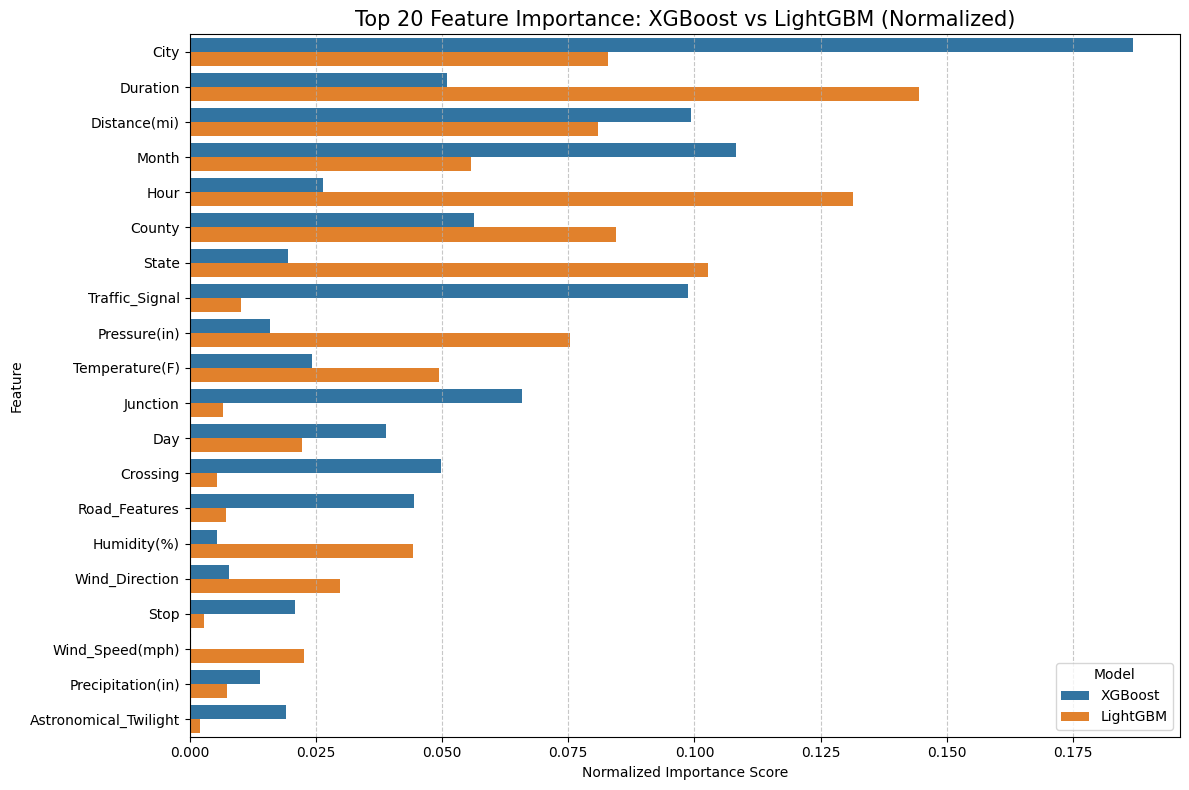

In [ ]:
def plot_ensemble_feature_importance(ensemble_model, feature_names):
    xgb_model = ensemble_model.named_estimators_['xgb']
    lgb_model = ensemble_model.named_estimators_['lgb']

    xgb_importance = xgb_model.feature_importances_ / xgb_model.feature_importances_.sum()
    lgb_importance = lgb_model.feature_importances_ / lgb_model.feature_importances_.sum()

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'XGBoost': xgb_importance,
        'LightGBM': lgb_importance
    })

    importance_df['Average'] = (importance_df['XGBoost'] + importance_df['LightGBM']) / 2
    importance_df = importance_df.sort_values(by='Average', ascending=False).head(20) # Ambil top 20

    plt.figure(figsize=(12, 8))

    df_plot = importance_df.melt(id_vars='Feature', value_vars=['XGBoost', 'LightGBM'],
                                 var_name='Model', value_name='Importance')

    sns.barplot(data=df_plot, y='Feature', x='Importance', hue='Model')

    plt.title('Top 20 Feature Importance: XGBoost vs LightGBM (Normalized)', fontsize=15)
    plt.xlabel('Normalized Importance Score')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_ensemble_feature_importance(best_ensemble, X_train.columns)

# Menyimpan Model ke .pkl

## Model Terakhir

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

y_train_shifted = y_train.astype(int) - 1
y_test_shifted = y_test.astype(int) - 1
y_test_int = y_test.astype(int)

model_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    tree_method='hist',
    enable_categorical=True,
    random_state=42,
    subsample=1.0,          
    n_estimators=500,
    max_depth=9,
    learning_rate=0.01,
    gamma=0,
    colsample_bytree=0.6
)

model_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1,
    importance_type='gain',
    reg_lambda=0,
    reg_alpha=0.5,
    num_leaves=127,
    n_estimators=300,
    min_child_samples=50,
    learning_rate=0.05,
    bagging_fraction=1.0,    
    bagging_freq=0
)

best_ensemble = VotingClassifier(
    estimators=[
        ('xgb', model_xgb),
        ('lgb', model_lgb)
    ],
    voting='soft',
    weights=[1, 1.5]
)

if isinstance(X_train, pd.DataFrame):
    X_full = pd.concat([X_train, X_test], axis=0)
    y_full_shifted = pd.concat([pd.Series(y_train_shifted), pd.Series(y_test_shifted)], axis=0)
else:
    X_full = np.vstack((X_train, X_test))
    y_full_shifted = np.concatenate((y_train_shifted, y_test_shifted))

print(f"Melatih Model Ensemble pada seluruh dataset ({X_full.shape[0]} baris)...")
best_ensemble.fit(X_full, y_full_shifted)

y_pred_final = best_ensemble.predict(X_test) + 1

print("\n" + "="*50)
print("=== LAPORAN KLASIFIKASI ENSEMBLE (FULL DATA) ===")
print("="*50)
print(classification_report(y_test_int, y_pred_final))

print(f"Final Accuracy Score: {accuracy_score(y_test_int, y_pred_final):.4f}")
print(f"Final F1 Macro Score: {f1_score(y_test_int, y_pred_final, average='macro'):.4f}")

Melatih Model Ensemble pada seluruh dataset (1178913 baris)...
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.757015 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1909
[LightGBM] [Info] Number of data points in the train set: 1178913, number of used features: 38
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training f

In [27]:
y_pred_train = best_ensemble.predict(X_train) + 1
y_train_int = y_train.astype(int)

print("\n" + "="*50)
print("=== LAPORAN KLASIFIKASI ENSEMBLE (DATA TRAIN) ===")
print("="*50)
print(classification_report(y_train_int, y_pred_train))

print(f"Train Accuracy Score: {accuracy_score(y_train_int, y_pred_train):.4f}")
print(f"Train F1 Macro Score: {f1_score(y_train_int, y_pred_train, average='macro'):.4f}")

[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0

=== LAPORAN KLASIFIKASI ENSEMBLE (DATA TRAIN) ===
              precision    recall  f1-score   support

           1       0.57      0.97      0.72     22697
           2       0.95      0.87      0.91    747298
           3       0.61      0.74      0.67    148281
           4       0.42      0.76      0.54     24854

    accuracy                           0.85    943130
   macro avg       0.64      0.83      0.71    943130
weighted avg       0.88      0.85      0.86    943130

Train Accuracy Score: 0.8471
Train F1 Macro Score: 0.7096


In [28]:
import joblib

filename = 'best_model_severity.pkl'

joblib.dump(best_ensemble, filename)

print("Penyimpanan berhasil!")


Penyimpanan berhasil!


In [24]:
y_train_shifted = y_train.astype(int) - 1
y_test_shifted = y_test.astype(int) - 1
y_test_int = y_test.astype(int)

if isinstance(X_train, pd.DataFrame):
    X_full = pd.concat([X_train, X_test], axis=0)
    y_full_shifted = pd.concat([pd.Series(y_train_shifted), pd.Series(y_test_shifted)], axis=0)
else:
    X_full = np.vstack((X_train, X_test))
    y_full_shifted = np.concatenate((y_train_shifted, y_test_shifted))

In [ ]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load model .pkl kamu
# Ganti 'nama_model_kamu.pkl' dengan path file yang sesuai
model = joblib.load('best_model_severity.pkl')

# 2. Lakukan prediksi
# Gunakan X_test yang sesuai dengan format saat training
y_pred_shifted = model.predict(X_test)

# 3. Buat Confusion Matrix
# Kita bandingkan y_test_shifted (aktual) dengan y_pred_shifted (prediksi)
cm = confusion_matrix(y_test_shifted, y_pred_shifted)

# 4. Visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test_int), 
            yticklabels=np.unique(y_test_int))

plt.title('Confusion Matrix')
plt.xlabel('Prediksi (Label Asli)')
plt.ylabel('Aktual (Label Asli)')
plt.show()

# 5. Opsional: Print Classification Report untuk detail precision/recall
print(classification_report(y_test_shifted, y_pred_shifted))